<a href="https://colab.research.google.com/github/anp2/Declarative-Pipeline/blob/master/EcommProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CustomersData.csv to CustomersData.csv
Saving Discount_Coupon.csv to Discount_Coupon.csv
Saving Marketing_Spend.csv to Marketing_Spend.csv
Saving Online_Sales.csv to Online_Sales.csv
Saving Tax_amount.xlsx to Tax_amount.xlsx


In [3]:
customer_df = pd.read_csv('CustomersData.csv')

disc_coupon_df = pd.read_csv('Discount_Coupon.csv')

sales_df = pd.read_csv('Online_Sales.csv')

marketing_df = pd.read_csv('Marketing_Spend.csv')

tax_df = pd.read_excel('Tax_amount.xlsx')

In [4]:
print("Customer Data")
display(customer_df.head())

print("Discount Coupon")
display(disc_coupon_df.head())

print("Online Sales")
display(sales_df.head())

print("Marketing Spend")
display(marketing_df.head())

print("Tax Data")
display(tax_df.head())

Customer Data


,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


Discount Coupon


,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


Online Sales


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


Marketing Spend


,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


Tax Data


,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [5]:
print("Customer Data:", customer_df.shape)

print("Doscount Coupon:", disc_coupon_df.shape)

print("Online Sales:", sales_df.shape)

print("Marketing Spend:", marketing_df.shape)

print("Tax Data:", tax_df.shape)

Customer Data: (1468, 4)
Doscount Coupon: (204, 4)
Online Sales: (52924, 10)
Marketing Spend: (365, 3)
Tax Data: (20, 2)


In [6]:
customer_df.info()

disc_coupon_df.info()

sales_df.info()

marketing_df.info()

tax_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtyp

In [7]:
print(customer_df.dtypes)

CustomerID        int64
Gender           object
Location         object
Tenure_Months     int64
dtype: object


In [8]:
print(disc_coupon_df.dtypes)

Month               object
Product_Category    object
Coupon_Code         object
Discount_pct         int64
dtype: object


In [9]:
print(sales_df.dtypes)

CustomerID               int64
Transaction_ID           int64
Transaction_Date        object
Product_SKU             object
Product_Description     object
Product_Category        object
Quantity                 int64
Avg_Price              float64
Delivery_Charges       float64
Coupon_Status           object
dtype: object


In [10]:
print(marketing_df.dtypes)

Date              object
Offline_Spend      int64
Online_Spend     float64
dtype: object


In [11]:
print(tax_df.dtypes)

Product_Category     object
GST                 float64
dtype: object


In [12]:
sales_df['CustomerID'] = sales_df['CustomerID'].astype(str)


In [13]:
sales_df['Transaction_ID'] = sales_df['Transaction_ID'].astype(str)

In [14]:
sales_df['Product_SKU'] = sales_df['Product_SKU'].astype(str)

In [15]:
customer_df['CustomerID'] = customer_df['CustomerID'].astype(str)

In [16]:
print(sales_df.dtypes)

CustomerID              object
Transaction_ID          object
Transaction_Date        object
Product_SKU             object
Product_Description     object
Product_Category        object
Quantity                 int64
Avg_Price              float64
Delivery_Charges       float64
Coupon_Status           object
dtype: object


In [17]:
sales_df['Transaction_Date'] = pd.to_datetime(
    sales_df['Transaction_Date']
)

marketing_df['Date'] = pd.to_datetime(
    marketing_df['Date']
)

In [18]:
print(marketing_df.dtypes)

Date             datetime64[ns]
Offline_Spend             int64
Online_Spend            float64
dtype: object


In [19]:
for name, df in customer_df.items():

    print('=' * 60)

    print(name)

    print('=' * 60)

    print(df.isnull().sum())

    print('\n')

CustomerID
0


Gender
0


Location
0


Tenure_Months
0




In [20]:
for name, df in customer_df.items():

    print('=' * 60)

    print(name)

    print('=' * 60)

    missing_pct = (
        df.isnull().sum()
        / len(df)
    ) * 100

    print(
        missing_pct.round(2)
    )

    print('\n')

CustomerID
0.0


Gender
0.0


Location
0.0


Tenure_Months
0.0




In [21]:
sales_df.describe()

,Transaction_Date,Quantity,Avg_Price,Delivery_Charges
count,52924,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000
std,NaN,20.104711,64.006882,19.475613


In [22]:
sales_df['Month'] = sales_df['Transaction_Date'].dt.month_name()

In [23]:
sales_df.describe()

,Transaction_Date,Quantity,Avg_Price,Delivery_Charges
count,52924,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000
std,NaN,20.104711,64.006882,19.475613


In [24]:
marketing_df['Month'] = marketing_df['Date'].dt.month_name()

In [25]:
marketing_df.describe()

,Date,Offline_Spend,Online_Spend
count,365,365.000000,365.000000
mean,2019-07-02 00:00:00,2843.561644,1905.880740
min,2019-01-01 00:00:00,500.000000,320.250000
25%,2019-04-02 00:00:00,2500.000000,1258.600000
50%,2019-07-02 00:00:00,3000.000000,1881.940000
75%,2019-10-01 00:00:00,3500.000000,2435.120000
max,2019-12-31 00:00:00,5000.000000,4556.930000
std,NaN,952.292448,808.856853


In [26]:
merged_df = sales_df.merge(
    customer_df,
    on='CustomerID',
    how='left'
)

In [27]:
print(merged_df.shape)

merged_df.head()

(52924, 14)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12


In [28]:
merged_df = merged_df.merge(
    tax_df,
    on='Product_Category',
    how='left'
)

In [29]:
print(merged_df.shape)

merged_df.head()

(52924, 15)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months,GST
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18


In [30]:
merged_df = merged_df.merge(
    disc_coupon_df,
    on=['Month', 'Product_Category'],
    how='left'
)

In [31]:
print(merged_df.shape)

merged_df.head()

(52924, 17)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18,NaN,NaN
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18,NaN,NaN


In [32]:
merged_df = merged_df.merge(
    marketing_df,
    left_on='Transaction_Date',
    right_on='Date',
    how='left'
)

In [33]:
print(merged_df.shape)

merged_df.head()

(52924, 21)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Date,Offline_Spend,Online_Spend,Month_y
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,M,Chicago,12,0.18,NaN,NaN,2019-01-01,4500,2424.5,January
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,M,Chicago,12,0.18,NaN,NaN,2019-01-01,4500,2424.5,January


In [34]:
merged_df.drop(
    columns='Date',
    inplace=True
)

In [35]:
print(merged_df.shape)

merged_df.head()

(52924, 20)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_x,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18,NaN,NaN,4500,2424.5,January
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18,NaN,NaN,4500,2424.5,January


In [36]:
merged_df.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Month_x', 'Gender', 'Location',
       'Tenure_Months', 'GST', 'Coupon_Code', 'Discount_pct', 'Offline_Spend',
       'Online_Spend', 'Month_y'],
      dtype='object')

In [37]:
merged_df.isnull().sum()

,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


In [38]:
(
    merged_df.isnull().sum()
    / len(merged_df)
) * 100

,0
CustomerID,0.000000
Transaction_ID,0.000000
Transaction_Date,0.000000
Product_SKU,0.000000
Product_Description,0.000000
Product_Category,0.000000
Quantity,0.000000
Avg_Price,0.000000
Delivery_Charges,0.000000
Coupon_Status,0.000000


In [39]:
merged_df['GST'] = (
    merged_df['GST']
    .fillna(0)
)

merged_df['Discount_pct'] = (
    merged_df['Discount_pct']
    .fillna(0)
)

In [40]:
merged_df['Offline_Spend'] = (
    merged_df['Offline_Spend']
    .fillna(0)
)

merged_df['Online_Spend'] = (
    merged_df['Online_Spend']
    .fillna(0)
)

In [41]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  object        
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_x              52924 non-null  object        
 11  Gender               52924 non-null  object        
 12  Location             52924 non-null  object        
 13  Tenure_Months        52924 non-

In [42]:
required_columns = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]

print(merged_df[required_columns].head())

   Quantity  Avg_Price  Discount_pct   GST  Delivery_Charges
0         1     153.71           0.0  0.10               6.5
1         1     153.71           0.0  0.10               6.5
2         1       2.05           0.0  0.10               6.5
3         5      17.53           0.0  0.18               6.5
4         1      16.50           0.0  0.18               6.5


In [43]:
numeric_cols = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]

for col in numeric_cols:

    merged_df[col] = pd.to_numeric(
        merged_df[col],
        errors='coerce'
    )

In [44]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  object        
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_x              52924 non-null  object        
 11  Gender               52924 non-null  object        
 12  Location             52924 non-null  object        
 13  Tenure_Months        52924 non-

In [45]:
merged_df[numeric_cols] = (
    merged_df[numeric_cols]
    .fillna(0)
)

In [46]:
merged_df[numeric_cols]

,Quantity,Avg_Price,Discount_pct,GST,Delivery_Charges
0,1,153.71,0.0,0.10,6.50
1,1,153.71,0.0,0.10,6.50
2,1,2.05,0.0,0.10,6.50
3,5,17.53,0.0,0.18,6.50
4,1,16.50,0.0,0.18,6.50
...,...,...,...,...,...
52919,1,121.30,0.0,0.10,6.50
52920,1,48.92,0.0,0.18,6.50
52921,1,151.88,0.0,0.10,6.50
52922,5,80.52,0.0,0.10,6.50


In [47]:
if merged_df['Discount_pct'].max() > 1:

    merged_df['Discount_pct'] = (
        merged_df['Discount_pct'] / 100
    )

In [48]:
 merged_df['Discount_pct']

,Discount_pct
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
52919,0.0
52920,0.0
52921,0.0
52922,0.0


In [49]:
if merged_df['GST'].max() > 1:

    merged_df['GST'] = (
        merged_df['GST'] / 100
    )

In [50]:
print(
    merged_df[
        ['Discount_pct','GST']
    ].head()
)

   Discount_pct   GST
0           0.0  0.10
1           0.0  0.10
2           0.0  0.10
3           0.0  0.18
4           0.0  0.18


In [51]:
merged_df['Base_Amount'] = (
    merged_df['Quantity']
    * merged_df['Avg_Price']
)

In [52]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,2.05
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,M,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,87.65
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,M,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,F,New York,45,0.10,NaN,0.0,4000,2058.75,December,121.30
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,F,New York,45,0.18,NaN,0.0,4000,2058.75,December,48.92
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,F,New York,45,0.10,NaN,0.0,4000,2058.75,December,151.88
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,F,California,7,0.10,NaN,0.0,4000,2058.75,December,402.60


In [53]:
merged_df['Discounted_Amount'] = (
    merged_df['Base_Amount']
    * (1 - merged_df['Discount_pct'])
)

In [54]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,New York,45,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,New York,45,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,New York,45,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,California,7,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60


In [55]:
merged_df['Taxed_Amount'] = (
    merged_df['Discounted_Amount']
    * (1 + merged_df['GST'])
)

In [56]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05,2.2550
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,12,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65,103.4270
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,12,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50,19.4700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,45,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30,133.4300
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,45,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92,57.7256
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,45,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88,167.0680
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,7,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60,442.8600


In [57]:
merged_df['Invoice_Value'] = (

    merged_df['Taxed_Amount']

    + merged_df['Delivery_Charges']

)

In [58]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810,175.5810
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810,175.5810
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05,2.2550,8.7550
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65,103.4270,109.9270
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50,19.4700,25.9700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30,133.4300,139.9300
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92,57.7256,64.2256
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88,167.0680,173.5680
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60,442.8600,449.3600


In [59]:
merged_df[[
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges',
    'Invoice_Value'
]].head()

,Quantity,Avg_Price,Discount_pct,GST,Delivery_Charges,Invoice_Value
0,1,153.71,0.0,0.10,6.5,175.581
1,1,153.71,0.0,0.10,6.5,175.581
2,1,2.05,0.0,0.10,6.5,8.755
3,5,17.53,0.0,0.18,6.5,109.927
4,1,16.50,0.0,0.18,6.5,25.970


In [60]:
total_revenue = (
    merged_df['Invoice_Value']
    .sum()
)

print(
    f'Total Revenue: ₹{total_revenue:,.2f}'
)

Total Revenue: ₹5,673,745.82


In [61]:
total_orders = (
    merged_df['Transaction_ID']
    .nunique()
)

print(
    f'Total Orders: {total_orders}'
)

Total Orders: 25061


In [62]:
total_customers = (
    merged_df['CustomerID']
    .nunique()
)

print(
    f'Total Customers: {total_customers}'
)

Total Customers: 1468


In [63]:
aov = (
    total_revenue
    / total_orders
)

print(
    f'Average Order Value: ₹{aov:,.2f}'
)

Average Order Value: ₹226.40


In [64]:
merged_df[['Invoice_Value']].describe()

,Invoice_Value
count,52924.000000
mean,107.205537
std,181.734258
min,4.861600
25%,21.094560
50%,47.288200
75%,141.547000
max,11044.009500


In [65]:
# 1. Identify the months with the highest and lowest customer acquisition count.
# What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?

In [66]:
# Find each customer's first purchase date
customer_acquisition = (
    sales_df
    .groupby('CustomerID')['Transaction_Date']
    .min()
    .reset_index()
)

customer_acquisition.rename(
    columns={
        'Transaction_Date':'First_Purchase_Date'
    },
    inplace=True
)

customer_acquisition.head()

,CustomerID,First_Purchase_Date
0,12346,2019-09-15
1,12347,2019-03-24
2,12348,2019-06-22
3,12350,2019-12-14
4,12356,2019-09-15


In [67]:
# Extract Month
customer_acquisition['Acquisition_Month'] = (
    customer_acquisition['First_Purchase_Date']
    .dt.month_name()
)

In [68]:
customer_acquisition.head()

,CustomerID,First_Purchase_Date,Acquisition_Month
0,12346,2019-09-15,September
1,12347,2019-03-24,March
2,12348,2019-06-22,June
3,12350,2019-12-14,December
4,12356,2019-09-15,September


In [69]:
# Count Customer Acquisitions by Month
monthly_acquisition = (
    customer_acquisition
    .groupby('Acquisition_Month')
    .size()
    .reset_index(name='Customer_Count')
)

In [70]:
customer_acquisition.head()

,CustomerID,First_Purchase_Date,Acquisition_Month
0,12346,2019-09-15,September
1,12347,2019-03-24,March
2,12348,2019-06-22,June
3,12350,2019-12-14,December
4,12356,2019-09-15,September


In [71]:
# Sort Months Chronologically
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_acquisition['Acquisition_Month'] = pd.Categorical(
    monthly_acquisition['Acquisition_Month'],
    categories=month_order,
    ordered=True
)

monthly_acquisition = (
    monthly_acquisition
    .sort_values('Acquisition_Month')
)

monthly_acquisition

,Acquisition_Month,Customer_Count
4,January,215
3,February,96
7,March,177
0,April,163
8,May,112
6,June,137
5,July,94
1,August,135
11,September,78
10,October,87


In [72]:
# Identify Highest and Lowest Acquisition Months
highest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmax()
]

lowest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmin()
]

print(
    f"Highest Acquisition Month: "
    f"{highest_month['Acquisition_Month']} "
    f"({highest_month['Customer_Count']} customers)"
)

print(
    f"Lowest Acquisition Month: "
    f"{lowest_month['Acquisition_Month']} "
    f"({lowest_month['Customer_Count']} customers)"
)

Highest Acquisition Month: January (215 customers)
Lowest Acquisition Month: November (68 customers)


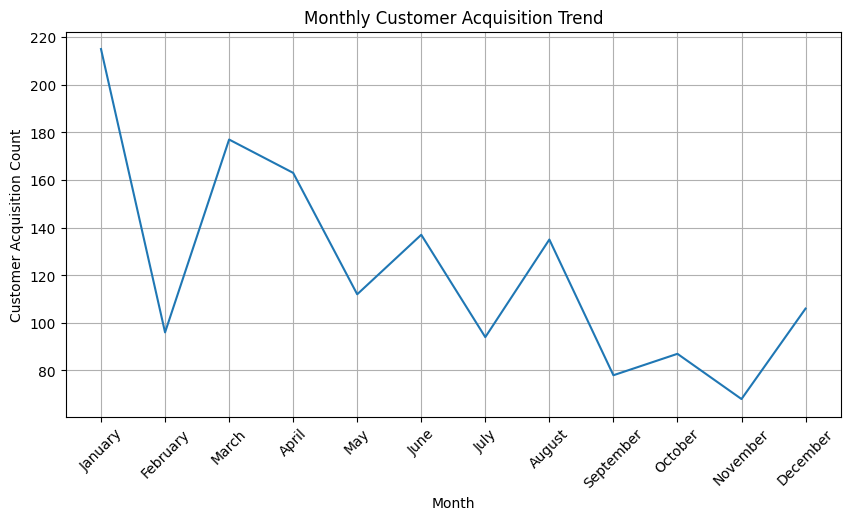

In [73]:
# Visualize the Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_acquisition['Acquisition_Month'],
    monthly_acquisition['Customer_Count']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Customer Acquisition Count')

plt.title('Monthly Customer Acquisition Trend')

plt.grid(True)

plt.show()

In [74]:
# Customer acquisition was defined as a customer's first purchase.
# The earliest transaction date for each customer was identified and grouped by month to calculate monthly acquisition counts.
# The months with the highest and lowest acquisition were then determined.
# To reduce fluctuations and ensure steady growth, strategies such as increasing marketing efforts during low-performing months,
# offering promotions, implementing referral programs, and replicating successful campaigns from high-performing months are recommended.

# 2. Analyze Monthly Customer Acquisition Trends

In [75]:
monthly_acquisition

,Acquisition_Month,Customer_Count
4,January,215
3,February,96
7,March,177
0,April,163
8,May,112
6,June,137
5,July,94
1,August,135
11,September,78
10,October,87


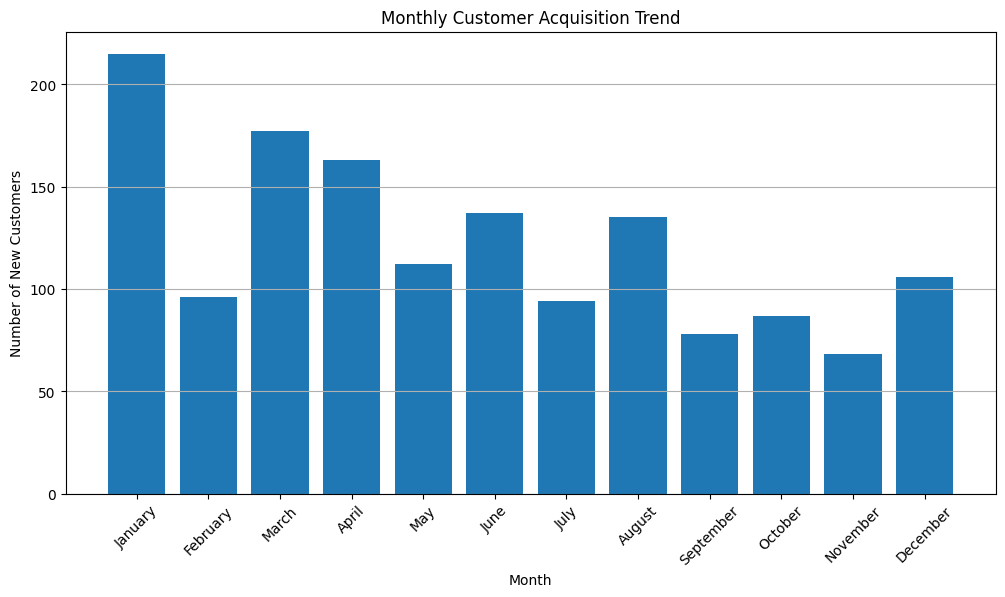

In [76]:
# Visualize Monthly Acquisition Trends
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    monthly_acquisition['Acquisition_Month'],
    monthly_acquisition['Customer_Count']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Number of New Customers')

plt.title('Monthly Customer Acquisition Trend')

plt.grid(axis='y')

plt.show()

In [77]:
# Calculate Average Monthly Acquisition

average_acquisition = (
    monthly_acquisition['Customer_Count']
    .mean()
)

print(
    f'Average Monthly Acquisition: '
    f'{average_acquisition:.0f}'
)

Average Monthly Acquisition: 122


In [78]:
# Categorize Months
# Identify months that perform above and below average.
monthly_acquisition['Performance'] = (
    monthly_acquisition['Customer_Count']
    .apply(
        lambda x:
        'High'
        if x >= average_acquisition
        else 'Low'
    )
)

monthly_acquisition

,Acquisition_Month,Customer_Count,Performance
4,January,215,High
3,February,96,Low
7,March,177,High
0,April,163,High
8,May,112,Low
6,June,137,High
5,July,94,Low
1,August,135,High
11,September,78,Low
10,October,87,Low


In [79]:
# Identify High and Low Performing Months
high_months = monthly_acquisition[
    monthly_acquisition['Performance']
    == 'High'
]

low_months = monthly_acquisition[
    monthly_acquisition['Performance']
    == 'Low'
]

print('High Performing Months')

display(high_months)

print('Low Performing Months')

display(low_months)

High Performing Months


,Acquisition_Month,Customer_Count,Performance
4,January,215,High
7,March,177,High
0,April,163,High
6,June,137,High
1,August,135,High


Low Performing Months


,Acquisition_Month,Customer_Count,Performance
3,February,96,Low
8,May,112,Low
5,July,94,Low
11,September,78,Low
10,October,87,Low
9,November,68,Low
2,December,106,Low


3. Identify periods with the strongest and weakest retention **rates** **bold text**

In [80]:
# Create Year-Month Column

sales_df['Year_Month'] = (
    sales_df['Transaction_Date']
    .dt.to_period('M')
)

In [81]:
sales_df['Year_Month']

,Year_Month
0,2019-01
1,2019-01
2,2019-01
3,2019-01
4,2019-01
...,...
52919,2019-12
52920,2019-12
52921,2019-12
52922,2019-12


In [82]:
# Create Monthly Customer Lists
# Group customers for each month.
monthly_customers = (
    sales_df
    .groupby('Year_Month')['CustomerID']
    .apply(set)
    .sort_index()
)

monthly_customers.head()

,CustomerID
Year_Month,
2019-01,"{16552, 15525, 17961, 13255, 14001, 17951, 173..."
2019-02,"{14210, 15880, 15570, 14911, 15235, 17809, 172..."
2019-03,"{14282, 13963, 17428, 14081, 17019, 15628, 166..."
2019-04,"{14987, 17646, 17377, 15005, 16011, 17442, 164..."
2019-05,"{12540, 17428, 17338, 16011, 16499, 14505, 155..."


In [83]:
# Calculate Monthly Retention Rates

retention_data = []

months = monthly_customers.index.tolist()

for i in range(len(months)-1):

    current_month = months[i]

    next_month = months[i+1]

    current_customers = monthly_customers[current_month]

    next_customers = monthly_customers[next_month]

    retained_customers = (
        current_customers
        .intersection(next_customers)
    )

    retention_rate = (
        len(retained_customers)
        / len(current_customers)
    ) * 100

    retention_data.append({

        'Month': str(current_month),

        'Next_Month': str(next_month),

        'Customers_Current_Month': len(current_customers),

        'Retained_Customers': len(retained_customers),

        'Retention_Rate': round(
            retention_rate,
            2
        )
    })

In [84]:
retention_data[1]

{'Month': '2019-02',
 'Next_Month': '2019-03',
 'Customers_Current_Month': 109,
 'Retained_Customers': 11,
 'Retention_Rate': 10.09}

In [85]:
# Create Retention DataFrame
retention_df = pd.DataFrame(
    retention_data
)

retention_df

,Month,Next_Month,Customers_Current_Month,Retained_Customers,Retention_Rate
0,2019-01,2019-02,215,13,6.05
1,2019-02,2019-03,109,11,10.09
2,2019-03,2019-04,208,24,11.54
3,2019-04,2019-05,224,25,11.16
4,2019-05,2019-06,200,37,18.50
5,2019-06,2019-07,259,58,22.39
6,2019-07,2019-08,236,65,27.54
7,2019-08,2019-09,300,44,14.67
8,2019-09,2019-10,193,29,15.03
9,2019-10,2019-11,210,31,14.76


In [86]:
# Identify Strongest and Weakest Months

strongest = retention_df.loc[
    retention_df['Retention_Rate']
    .idxmax()
]

weakest = retention_df.loc[
    retention_df['Retention_Rate']
    .idxmin()
]

print(
    f"Strongest Retention: "
    f"{strongest['Month']} "
    f"({strongest['Retention_Rate']}%)"
)

print(
    f"Weakest Retention: "
    f"{weakest['Month']} "
    f"({weakest['Retention_Rate']}%)"
)

Strongest Retention: 2019-07 (27.54%)
Weakest Retention: 2019-01 (6.05%)


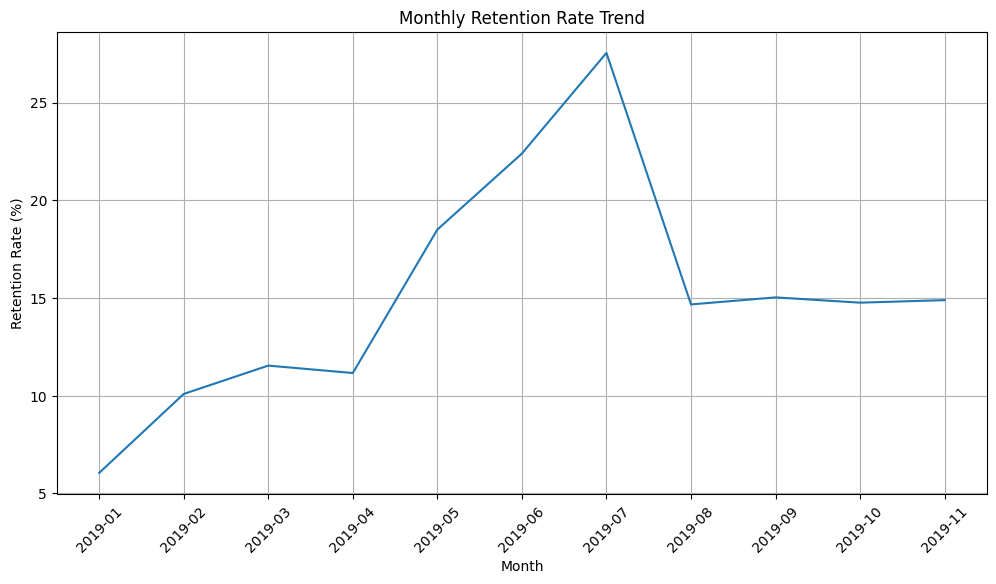

In [87]:
# Visualize Retention Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    retention_df['Month'],
    retention_df['Retention_Rate']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Retention Rate (%)')

plt.title('Monthly Retention Rate Trend')

plt.grid(True)

plt.show()

**4. Analyze customer behavior during high-retention months**

In [88]:
# Identify High-Retention Months

top_retention_months = (
    retention_df
    .sort_values(
        by='Retention_Rate',
        ascending=False
    )
    .head(3)
)

top_retention_months

,Month,Next_Month,Customers_Current_Month,Retained_Customers,Retention_Rate
6,2019-07,2019-08,236,65,27.54
5,2019-06,2019-07,259,58,22.39
4,2019-05,2019-06,200,37,18.50


In [89]:
# Extract those months.

high_retention_months = (
    top_retention_months['Month']
    .tolist()
)

high_retention_months

['2019-07', '2019-06', '2019-05']

In [90]:
# Filter Transactions
# Create Year_Month.

merged_df['Year_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
    .astype(str)
)

high_retention_sales = merged_df[
    merged_df['Year_Month']
    .isin(high_retention_months)
]


In [91]:
# Analyze Product Categories

category_analysis = (
    high_retention_sales
    .groupby('Product_Category')
    ['Quantity']
    .sum()
    .sort_values(
        ascending=False
    )
)

category_analysis

,Quantity
Product_Category,
Office,22728
Apparel,9687
Drinkware,8164
Lifestyle,7171
Nest-USA,4882
Bags,3858
Notebooks & Journals,3194
Housewares,1222
Bottles,775


In [92]:
# Analyze Coupon Usage

coupon_analysis = (
    high_retention_sales
    ['Coupon_Status']
    .value_counts()
)

coupon_analysis

,count
Coupon_Status,
Clicked,7187
Used,4668
Not Used,2161


In [93]:
# Calculate percentages.

coupon_percentage = (

    high_retention_sales['Coupon_Status'].value_counts(normalize=True) * 100

).round(2)

coupon_percentage

,proportion
Coupon_Status,
Clicked,51.28
Used,33.30
Not Used,15.42


In [94]:
# Analyze Invoice Value
# If Invoice_Value already exists:

invoice_analysis = (
    high_retention_sales['Invoice_Value'].describe()
)

invoice_analysis

,Invoice_Value
count,14016.000000
mean,84.250018
std,142.725648
min,6.695200
25%,18.828960
50%,31.950400
75%,117.710000
max,4727.850000


In [95]:
# Analyze Purchase Frequency

purchase_frequency = (

    high_retention_sales

    .groupby('CustomerID')

    ['Transaction_ID']

    .nunique()

)

purchase_frequency.describe()

,Transaction_ID
count,573.000000
mean,11.373473
std,12.759069
min,1.000000
25%,3.000000
50%,7.000000
75%,15.000000
max,93.000000


In [96]:
# Analyze Top Products

top_products = (

    high_retention_sales

    .groupby('Product_Description')

    ['Quantity']

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

)

top_products

,Quantity
Product_Description,
Google 22 oz Water Bottle,4420
Maze Pen,4044
Google Sunglasses,3643
Recycled Paper Journal Set,2406
Sport Bag,1912
Google Kick Ball,1884
Foam Can and Bottle Cooler,1456
Google Metallic Notebook Set,1303
Nest Cam Outdoor Security Camera - USA,1283


In [97]:
# Create a Summary Table

summary = {

    'Average Invoice Value':

        high_retention_sales[
            'Invoice_Value'
        ].mean(),

    'Average Quantity Purchased':

        high_retention_sales[
            'Quantity'
        ].mean(),

    'Unique Customers':

        high_retention_sales[
            'CustomerID'
        ].nunique(),

    'Total Transactions':

        high_retention_sales[
            'Transaction_ID'
        ].nunique()

}

summary

{'Average Invoice Value': np.float64(84.25001807648401),
 'Average Quantity Purchased': np.float64(4.511415525114155),
 'Unique Customers': 573,
 'Total Transactions': 6054}

In [98]:
merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,NaN,0.0,4500,2424.5,January,153.71,153.71,169.081,175.581,2019-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,NaN,0.0,4500,2424.5,January,153.71,153.71,169.081,175.581,2019-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,NaN,0.0,4500,2424.5,January,2.05,2.05,2.255,8.755,2019-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,NaN,0.0,4500,2424.5,January,87.65,87.65,103.427,109.927,2019-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,NaN,0.0,4500,2424.5,January,16.50,16.50,19.470,25.970,2019-01




```
# For Question 5, the goal is to compare monthly revenue from New Customers # vs Existing Customers.

# Definitions
# New Customer: A customer making their first-ever purchase in that month.
# Existing Customer: A customer who has purchased before that month.
```

In [99]:
# Sort the data
merged_df = merged_df.sort_values(
    ['Transaction_Date', 'CustomerID']
)


In [100]:
# Find each customer's first purchase month

first_purchase = (
    merged_df
    .groupby('CustomerID')['Year_Month']
    .min()
    .reset_index()
)

first_purchase.rename(
    columns={'Year_Month':'First_Purchase_Month'},
    inplace=True
)

first_purchase.head()

,CustomerID,First_Purchase_Month
0,12346,2019-09
1,12347,2019-03
2,12348,2019-06
3,12350,2019-12
4,12356,2019-09


In [101]:
# Merge back to the main dataset

merged_df = merged_df.merge(
    first_purchase,
    on='CustomerID',
    how='left'
)

In [102]:
merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,0.0,4500,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,0.0,4500,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,0.0,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,0.0,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,0.0,4500,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01


In [103]:
# Classify customers

merged_df['Customer_Type'] = np.where(

    merged_df['Year_Month']
    == merged_df['First_Purchase_Month'],

    'New',

    'Existing'

)

merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month,Customer_Type
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,4500,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01,New
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,4500,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01,New
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,4500,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01,New


In [104]:
# Calculate monthly revenue

monthly_revenue = (

    merged_df

    .groupby(
        ['Year_Month', 'Customer_Type']
    )

    ['Invoice_Value']

    .sum()

    .reset_index()

)

monthly_revenue.head()

,Year_Month,Customer_Type,Invoice_Value
0,2019-01,New,508514.7551
1,2019-02,Existing,49784.6856
2,2019-02,New,347080.9714
3,2019-03,Existing,74933.2394
4,2019-03,New,378271.8279


In [105]:
# Create a Pivot Table

revenue_pivot = (

    monthly_revenue

    .pivot(

        index='Year_Month',

        columns='Customer_Type',

        values='Invoice_Value'

    )

    .fillna(0)

)

revenue_pivot

Customer_Type,Existing,New
Year_Month,,
2019-01,0.00000,508514.75510
2019-02,49784.68560,347080.97140
2019-03,74933.23940,378271.82790
2019-04,201853.32260,290706.38430
2019-05,115067.71388,203488.58668
2019-06,160076.14910,236926.78480
2019-07,279620.57080,185668.44810
2019-08,263821.96240,243114.64760
2019-09,260016.98090,180805.44490


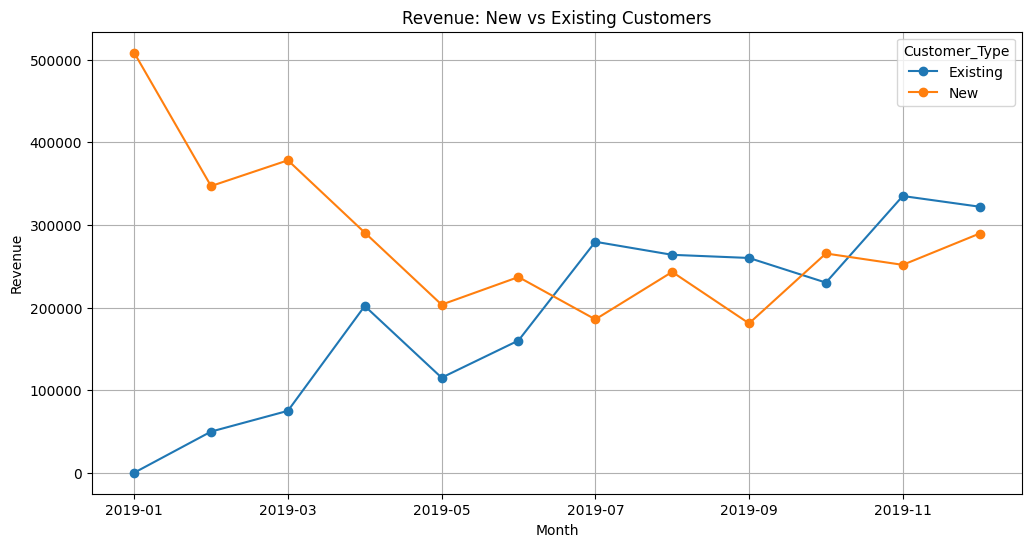

In [106]:
# Visualize the Trend

import matplotlib.pyplot as plt

revenue_pivot.plot(

    kind='line',

    figsize=(12,6),

    marker='o'

)

plt.title(
    'Revenue: New vs Existing Customers'
)

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.grid(True)

plt.show()

In [107]:
# Calculate Revenue Contribution (%)

revenue_pivot['Total_Revenue'] = (

    revenue_pivot['New']

    + revenue_pivot['Existing']

)

revenue_pivot['New_%'] = (

    revenue_pivot['New']

    / revenue_pivot['Total_Revenue']

) * 100

revenue_pivot['Existing_%'] = (

    revenue_pivot['Existing']

    / revenue_pivot['Total_Revenue']

) * 100

revenue_pivot.round(2)

Customer_Type,Existing,New,Total_Revenue,New_%,Existing_%
Year_Month,,,,,
2019-01,0.00,508514.76,508514.76,100.00,0.00
2019-02,49784.69,347080.97,396865.66,87.46,12.54
2019-03,74933.24,378271.83,453205.07,83.47,16.53
2019-04,201853.32,290706.38,492559.71,59.02,40.98
2019-05,115067.71,203488.59,318556.30,63.88,36.12
2019-06,160076.15,236926.78,397002.93,59.68,40.32
2019-07,279620.57,185668.45,465289.02,39.90,60.10
2019-08,263821.96,243114.65,506936.61,47.96,52.04
2019-09,260016.98,180805.44,440822.43,41.02,58.98


# **6. Analyze the relationship between coupon usage and revenue generation**

In [108]:
# Check Coupon Distribution

merged_df['Coupon_Status'].value_counts()

,count
Coupon_Status,
Clicked,26926
Used,17904
Not Used,8094


In [109]:
# Revenue by Coupon Usage

coupon_revenue = (

    merged_df

    .groupby('Coupon_Status')

    ['Invoice_Value']

    .sum()

    .reset_index()

)

coupon_revenue

,Coupon_Status,Invoice_Value
0,Clicked,2.889112e+06
1,Not Used,8.869004e+05
2,Used,1.897734e+06


In [110]:
# Calculate Revenue Share (%)

total_revenue = coupon_revenue['Invoice_Value'].sum()

coupon_revenue['Revenue_%'] = (

    coupon_revenue['Invoice_Value']

    / total_revenue

) * 100

coupon_revenue.round(2)

,Coupon_Status,Invoice_Value,Revenue_%
0,Clicked,2889111.77,50.92
1,Not Used,886900.44,15.63
2,Used,1897733.61,33.45


In [111]:
# Compare Average Transaction Values

avg_invoice = (

    merged_df

    .groupby('Coupon_Status')

    ['Invoice_Value']

    .mean()

    .reset_index()

)

avg_invoice

,Coupon_Status,Invoice_Value
0,Clicked,107.298216
1,Not Used,109.575049
2,Used,105.994951


In [112]:
# Statistical Test (T-Test)
# This helps determine whether the difference is statistically significant.

from scipy.stats import ttest_ind

coupon_users = (

    merged_df

    .loc[
        merged_df['Coupon_Status']=='Used',
        'Invoice_Value'
    ]

)

non_coupon_users = (

    merged_df

    .loc[
        merged_df['Coupon_Status']=='Not Used',
        'Invoice_Value'
    ]

)

t_stat, p_value = ttest_ind(

    coupon_users,

    non_coupon_users,

    equal_var=False

)

print('T-statistic:', t_stat)

print('P-value:', p_value)

T-statistic: -1.3995675804334649
P-value: 0.1616630817794477


In [113]:
# Interpret the Result

if p_value < 0.05:

    print(
        'Significant difference exists'
    )

else:

    print(
        'No significant difference exists'
    )

No significant difference exists


**# 7. Identify the top-performing products**

In [114]:
# Analyze Quantity Sold

top_quantity_products = (

    merged_df

    .groupby('Product_Description')

    ['Quantity']

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

)

top_quantity_products

,Quantity
Product_Description,
Maze Pen,16234
Google 22 oz Water Bottle,14282
Google Sunglasses,11452
Sport Bag,7321
Google Metallic Notebook Set,6496
Google Laptop and Cell Phone Stickers,5847
Google Kick Ball,5549
Recycled Paper Journal Set,5381
Nest Cam Outdoor Security Camera - USA,5206


In [115]:
# Analyze Revenue Generated

top_revenue_products = (

    merged_df

    .groupby('Product_Description')

    ['Invoice_Value']

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

)

top_revenue_products

,Invoice_Value
Product_Description,
Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,774602.444
Nest Cam Outdoor Security Camera - USA,707766.402
Nest Cam Indoor Security Camera - USA,595582.613
Nest Protect Smoke + CO White Battery Alarm-USA,240637.256
Nest Protect Smoke + CO White Wired Alarm-USA,238024.737
Nest Learning Thermostat 3rd Gen-USA - White,229231.060
Nest Secure Alarm System Starter Pack - USA,191824.307
Nest Cam IQ - USA,166339.836
Nest Thermostat E - USA,119965.912


In [116]:
# Combine Both Metrics

product_summary = (

    merged_df

    .groupby(

        ['Product_Category',

         'Product_Description']

    )

    .agg(

        Total_Quantity=(

            'Quantity',

            'sum'

        ),

        Total_Revenue=(

            'Invoice_Value',

            'sum'

        )

    )

    .reset_index()

)

product_summary

,Product_Category,Product_Description,Total_Quantity,Total_Revenue
0,Accessories,Android Large Removable Sticker Sheet,242,1033.36000
1,Accessories,Android Small Removable Sticker Sheet,330,1495.93900
2,Accessories,Emoji Sticker Sheet,247,2076.86300
3,Accessories,Google Emoji Sticker Pack,147,974.13300
4,Accessories,UpCycled Bike Saddle Bag,49,2055.73340
...,...,...,...,...
399,Waze,Waze Mood Happy Window Decal,36,331.20208
400,Waze,Waze Mood Ninja Window Decal,113,937.81020
401,Waze,Waze Mood Original Window Decal,256,1039.73004
402,Waze,Waze Women's Short Sleeve Tee,11,284.93740


In [117]:
# Identify Top Products

top_products = (

    product_summary

    .sort_values(

        by=[

            'Total_Revenue',

            'Total_Quantity'

        ],

        ascending=False

    )

    .head(10)

)

top_products

,Product_Category,Product_Description,Total_Quantity,Total_Revenue
331,Nest-USA,Nest Learning Thermostat 3rd Gen-USA - Stainle...,4570,774602.444
329,Nest-USA,Nest Cam Outdoor Security Camera - USA,5206,707766.402
328,Nest-USA,Nest Cam Indoor Security Camera - USA,4402,595582.613
335,Nest-USA,Nest Protect Smoke + CO White Battery Alarm-USA,2683,240637.256
336,Nest-USA,Nest Protect Smoke + CO White Wired Alarm-USA,2670,238024.737
332,Nest-USA,Nest Learning Thermostat 3rd Gen-USA - White,1368,229231.060
320,Nest,Nest Secure Alarm System Starter Pack - USA,510,191824.307
317,Nest,Nest Cam IQ - USA,771,166339.836
322,Nest,Nest Thermostat E - USA,1091,119965.912
330,Nest-USA,Nest Learning Thermostat 3rd Gen-USA - Copper,472,79385.268


In [118]:
# Analyze Category Performance

category_analysis = (

    merged_df

    .groupby('Product_Category')

    ['Invoice_Value']

    .sum()

    .sort_values(
        ascending=False
    )

)

category_analysis

,Invoice_Value
Product_Category,
Nest-USA,2.871085e+06
Apparel,8.605277e+05
Nest,5.601860e+05
Office,3.978568e+05
Drinkware,2.830873e+05
Bags,2.018448e+05
Lifestyle,1.296539e+05
Notebooks & Journals,1.270014e+05
Nest-Canada,8.007147e+04


In [119]:
# Check Coupon Usage

coupon_usage = (

    merged_df

    .groupby(

        'Product_Description'

    )

    ['Coupon_Status']

    .value_counts()

)

coupon_usage

Product_Description                      Coupon_Status
1 oz Hand Sanitizer                      Clicked          67
                                         Used             44
                                         Not Used         18
20 oz Stainless Steel Insulated Tumbler  Clicked          62
                                         Used             38
                                                          ..
YouTube Wool Heather Cap Heather/Black   Clicked           4
                                         Not Used          3
YouTube Youth Short Sleeve Tee Red       Clicked          54
                                         Used             44
                                         Not Used         18
Name: count, Length: 1176, dtype: int64

In [120]:
# Analyze Average Selling Price

price_analysis = (

    merged_df

    .groupby('Product_Description')

    ['Avg_Price']

    .mean()

    .sort_values(
        ascending=False
    )

)

price_analysis.head(10)

,Avg_Price
Product_Description,
Nest Secure Alarm System Starter Pack - USA,351.287269
Nest Cam IQ Outdoor - USA (Preorder),279.472973
Nest Cam IQ - CA,272.892500
Gift Card - $250.00,250.107111
Nest Learning Thermostat 3rd Gen - CA - Stainless Steel,199.940183
Nest Cam IQ - USA,199.916728
Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,150.981874
Nest Thermostat E - CA,150.350000
Nest Cam Indoor Security Camera - CA,150.030253


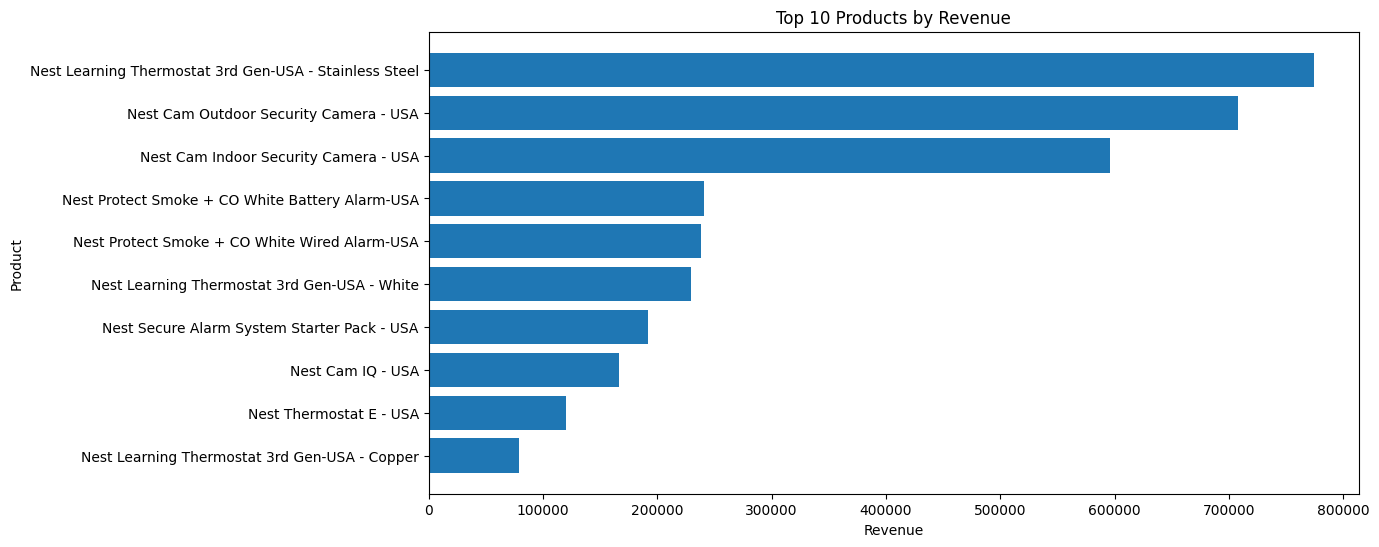

In [121]:
# Visualize Top Products by Revenue

import matplotlib.pyplot as plt

chart_data = (

    top_products

    .sort_values(

        by='Total_Revenue'

    )

)

plt.figure(figsize=(12,6))

plt.barh(

    chart_data['Product_Description'],

    chart_data['Total_Revenue']

)

plt.xlabel('Revenue')

plt.ylabel('Product')

plt.title('Top 10 Products by Revenue')

plt.show()

**8. Analyze the relationship between monthly marketing spend and revenue**

In [122]:
#
merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month,Customer_Type
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,4500,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01,New
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,4500,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01,New
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,4500,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01,New


In [123]:
# Calculate Monthly Revenue

monthly_revenue = (

    merged_df

    .groupby('Year_Month')

    ['Invoice_Value']

    .sum()

    .reset_index()

)

monthly_revenue

,Year_Month,Invoice_Value
0,2019-01,508514.75510
1,2019-02,396865.65700
2,2019-03,453205.06730
3,2019-04,492559.70690
4,2019-05,318556.30056
5,2019-06,397002.93390
6,2019-07,465289.01890
7,2019-08,506936.61000
8,2019-09,440822.42580
9,2019-10,495627.71850


In [124]:
# Calculate Monthly Marketing Spend

marketing_df['Year_Month'] = (
    marketing_df['Date']
    .dt.to_period('M')
)

In [125]:
monthly_marketing = (

    marketing_df

    .groupby('Year_Month')

    [['Online_Spend','Offline_Spend']]

    .sum()

    .reset_index()

)

In [126]:
# Create total spend:

monthly_marketing['Marketing_Spend'] = (

    monthly_marketing['Online_Spend']

    + monthly_marketing['Offline_Spend']

)

monthly_marketing.head()

,Year_Month,Online_Spend,Offline_Spend,Marketing_Spend
0,2019-01,58328.95,96600,154928.95
1,2019-02,55807.92,81300,137107.92
2,2019-03,48750.09,73500,122250.09
3,2019-04,61026.83,96000,157026.83
4,2019-05,52759.64,65500,118259.64


In [127]:
print(monthly_revenue['Year_Month'].dtype)

print(monthly_marketing['Year_Month'].dtype)

object
period[M]


In [128]:
monthly_revenue['Year_Month'] = (
    monthly_revenue['Year_Month']
    .astype(str)
)

monthly_marketing['Year_Month'] = (
    monthly_marketing['Year_Month']
    .astype(str)
)

In [129]:
print(monthly_revenue['Year_Month'].dtype)

print(monthly_marketing['Year_Month'].dtype)

object
object


In [130]:
# Merge Revenue and Marketing Data

marketing_analysis = monthly_revenue.merge(

    monthly_marketing[
        ['Year_Month','Marketing_Spend']
    ],

    on='Year_Month',

    how='left'

)

marketing_analysis.head()

,Year_Month,Invoice_Value,Marketing_Spend
0,2019-01,508514.75510,154928.95
1,2019-02,396865.65700,137107.92
2,2019-03,453205.06730,122250.09
3,2019-04,492559.70690,157026.83
4,2019-05,318556.30056,118259.64


**# 9. Evaluate the effectiveness of marketing campaigns**

In [131]:
# Calculate Marketing Spend %

# Formula: Marketing Spend% = Marketing Spend × 100 / Revenue

marketing_analysis['Marketing_Spend_%'] = (

    marketing_analysis['Marketing_Spend']

    * 100

    /

    marketing_analysis['Invoice_Value']

)

marketing_analysis.round(2)

,Year_Month,Invoice_Value,Marketing_Spend,Marketing_Spend_%
0,2019-01,508514.76,154928.95,30.47
1,2019-02,396865.66,137107.92,34.55
2,2019-03,453205.07,122250.09,26.97
3,2019-04,492559.71,157026.83,31.88
4,2019-05,318556.30,118259.64,37.12
5,2019-06,397002.93,134318.14,33.83
6,2019-07,465289.02,120217.85,25.84
7,2019-08,506936.61,142904.15,28.19
8,2019-09,440822.43,135514.54,30.74
9,2019-10,495627.72,151224.65,30.51


In [132]:
# Identify Efficient and Inefficient Months

best_month = marketing_analysis.loc[

    marketing_analysis['Marketing_Spend_%']

    .idxmin()

]

worst_month = marketing_analysis.loc[

    marketing_analysis['Marketing_Spend_%']

    .idxmax()

]

print(

    f"Most Efficient Month: "

    f"{best_month['Year_Month']} "

    f"({best_month['Marketing_Spend_%']:.2f}%)"

)

print(

    f"Worst Month: "

    f"{worst_month['Year_Month']} "

    f"({worst_month['Marketing_Spend_%']:.2f}%)"

)

Most Efficient Month: 2019-07 (25.84%)
Worst Month: 2019-05 (37.12%)


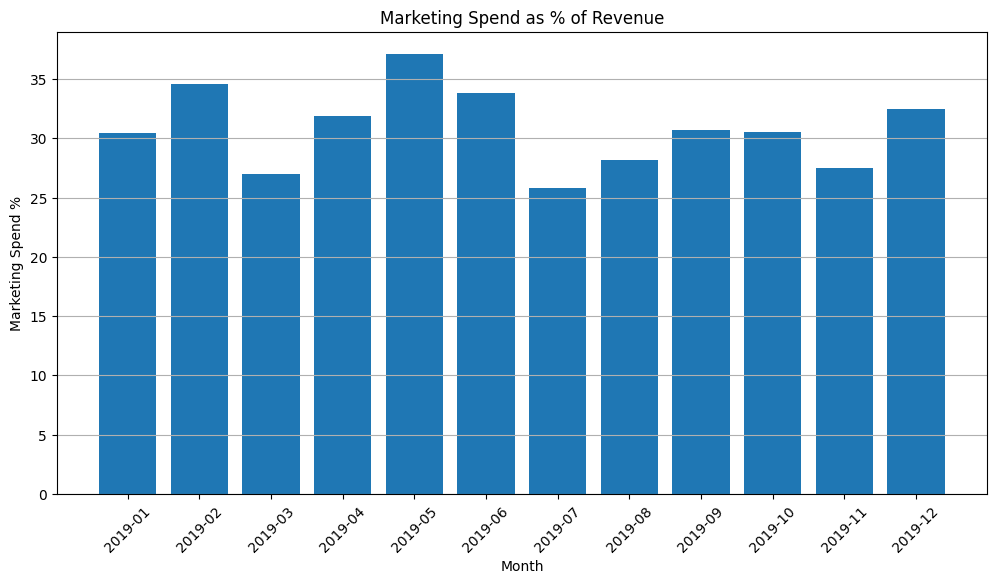

In [133]:
# Visualize Marketing Efficiency

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(

    marketing_analysis['Year_Month'],

    marketing_analysis['Marketing_Spend_%']

)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Marketing Spend %')

plt.title(

    'Marketing Spend as % of Revenue'

)

plt.grid(axis='y')

plt.show()

In [134]:
# Categorize Months

average_efficiency = (

    marketing_analysis['Marketing_Spend_%']

    .mean()

)

marketing_analysis['Performance'] = (

    marketing_analysis['Marketing_Spend_%']

    .apply(

        lambda x:

        'Efficient'

        if x <= average_efficiency

        else 'Needs Improvement'

    )

)

marketing_analysis

,Year_Month,Invoice_Value,Marketing_Spend,Marketing_Spend_%,Performance
0,2019-01,508514.75510,154928.95,30.466953,Efficient
1,2019-02,396865.65700,137107.92,34.547691,Needs Improvement
2,2019-03,453205.06730,122250.09,26.974564,Efficient
3,2019-04,492559.70690,157026.83,31.879755,Needs Improvement
4,2019-05,318556.30056,118259.64,37.123623,Needs Improvement
5,2019-06,397002.93390,134318.14,33.833035,Needs Improvement
6,2019-07,465289.01890,120217.85,25.837242,Efficient
7,2019-08,506936.61000,142904.15,28.189747,Efficient
8,2019-09,440822.42580,135514.54,30.741299,Efficient
9,2019-10,495627.71850,151224.65,30.511742,Efficient


**# 10. Segment customers using RFM**

In [135]:
# Define a reference date
# Use one day after the latest transaction date.

reference_date = (
    merged_df['Transaction_Date'].max()
    + pd.Timedelta(days=1)
)

print(reference_date)

2020-01-01 00:00:00


In [136]:
# Create RFM table

rfm = (

    merged_df

    .groupby('CustomerID')

    .agg(

        Recency=(

            'Transaction_Date',

            lambda x:
            (
                reference_date
                - x.max()
            ).days

        ),

        Frequency=(

            'Transaction_ID',

            'nunique'

        ),

        Monetary=(

            'Invoice_Value',

            'sum'

        )

    )

    .reset_index()

)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,108,1,185.6882
1,12347,60,31,16567.9470
2,12348,74,8,1842.8708
3,12350,18,11,1636.2142
4,12356,108,13,2231.7198


In [137]:
# Create RFM Scores
# Use quartiles.
# Recency
# Lower is better.
rfm['R_Score'] = pd.qcut(

    rfm['Recency'],

    q=4,

    labels=[4,3,2,1]

)

In [138]:
# Frequency - Higher is better.

rfm['F_Score'] = pd.qcut(

    rfm['Frequency'],

    q=4,

    labels=[1,2,3,4],

    duplicates='drop'

)

In [139]:
# Monetary - Higher is better.

rfm['M_Score'] = pd.qcut(

    rfm['Monetary'],

    q=4,

    labels=[1,2,3,4],

    duplicates='drop'

)

In [140]:
# Calculate Total RFM Score

rfm['RFM_Score'] = (

    rfm['R_Score']
    .astype(int)

    +

    rfm['F_Score']
    .astype(int)

    +

    rfm['M_Score']
    .astype(int)

)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,108,1,185.6882,3,1,1,5
1,12347,60,31,16567.9470,3,4,4,11
2,12348,74,8,1842.8708,3,2,2,7
3,12350,18,11,1636.2142,4,2,2,8
4,12356,108,13,2231.7198,3,3,3,9


In [141]:
# Create Customer Segments

def segment_customer(score):

    if score >= 10:

        return 'Premium'

    elif score >= 8:

        return 'Gold'

    elif score >= 6:

        return 'Silver'

    else:

        return 'Standard'

In [142]:
rfm['Customer_Segment'] = (

    rfm['RFM_Score']

    .apply(segment_customer)

)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,12346,108,1,185.6882,3,1,1,5,Standard
1,12347,60,31,16567.9470,3,4,4,11,Premium
2,12348,74,8,1842.8708,3,2,2,7,Silver
3,12350,18,11,1636.2142,4,2,2,8,Gold
4,12356,108,13,2231.7198,3,3,3,9,Gold


In [143]:
# Count Customers per Segment

segment_summary = (

    rfm

    ['Customer_Segment']

    .value_counts()

    .reset_index()

)

segment_summary.columns = [

    'Customer_Segment',

    'Customer_Count'

]

segment_summary

,Customer_Segment,Customer_Count
0,Standard,423
1,Premium,406
2,Silver,337
3,Gold,302


In [144]:
# Revenue by Segment

segment_revenue = (

    rfm

    .groupby(

        'Customer_Segment'

    )

    ['Monetary']

    .sum()

    .reset_index()

)

segment_revenue

,Customer_Segment,Monetary
0,Gold,1.212864e+06
1,Premium,3.631497e+06
2,Silver,5.727159e+05
3,Standard,2.566685e+05


In [145]:
# Analyze Segment Characteristics

rfm.groupby(

    'Customer_Segment'

)[

    ['Recency',

     'Frequency',

     'Monetary']

].mean().round(2)

,Recency,Frequency,Monetary
Customer_Segment,,,
Gold,140.73,18.69,4016.11
Premium,63.27,40.39,8944.57
Silver,152.56,9.02,1699.45
Standard,221.49,3.66,606.78


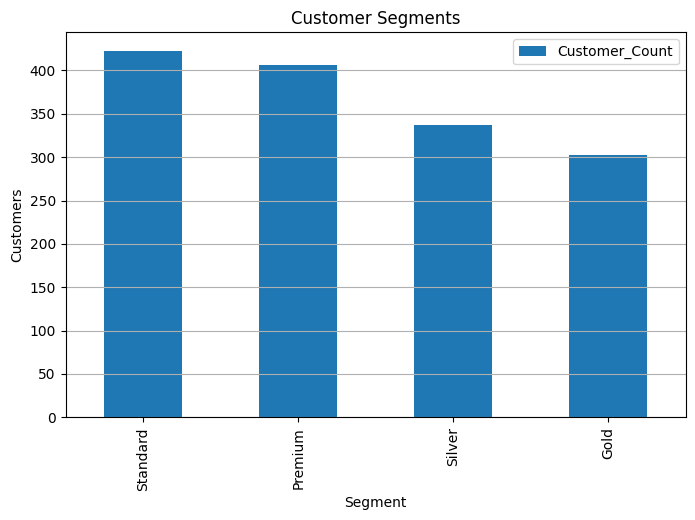

In [146]:
# Visualize Segments

import matplotlib.pyplot as plt

segment_summary.plot(

    kind='bar',

    x='Customer_Segment',

    y='Customer_Count',

    figsize=(8,5)

)

plt.title(

    'Customer Segments'

)

plt.xlabel(

    'Segment'

)

plt.ylabel(

    'Customers'

)

plt.grid(axis='y')

plt.show()

# **11 Analyze the revenue contribution of each customer segment**

In [147]:
# Revenue by Segment

segment_revenue = (

    rfm

    .groupby('Customer_Segment')

    ['Monetary']

    .sum()

    .reset_index()

)

segment_revenue

,Customer_Segment,Monetary
0,Gold,1.212864e+06
1,Premium,3.631497e+06
2,Silver,5.727159e+05
3,Standard,2.566685e+05


In [148]:
# Calculate Revenue Contribution %

total_revenue = (

    segment_revenue['Monetary']

    .sum()

)

segment_revenue['Revenue_Contribution_%'] = (

    segment_revenue['Monetary']

    * 100

    / total_revenue

)

segment_revenue.round(2)

,Customer_Segment,Monetary,Revenue_Contribution_%
0,Gold,1212864.32,21.38
1,Premium,3631497.14,64.01
2,Silver,572715.90,10.09
3,Standard,256668.45,4.52


In [149]:
# Calculate Customer Count

customer_count = (

    rfm

    .groupby('Customer_Segment')

    ['CustomerID']

    .count()

    .reset_index()

)

customer_count.rename(

    columns={

        'CustomerID':'Customer_Count'

    },

    inplace=True

)

customer_count

,Customer_Segment,Customer_Count
0,Gold,302
1,Premium,406
2,Silver,337
3,Standard,423


In [150]:
# Merge Revenue and Customer Count

segment_analysis = segment_revenue.merge(

    customer_count,

    on='Customer_Segment',

    how='left'

)

segment_analysis.round(2)

,Customer_Segment,Monetary,Revenue_Contribution_%,Customer_Count
0,Gold,1212864.32,21.38,302
1,Premium,3631497.14,64.01,406
2,Silver,572715.90,10.09,337
3,Standard,256668.45,4.52,423


In [151]:
# Average Revenue per Customer

segment_analysis['Avg_Revenue_Per_Customer'] = (

    segment_analysis['Monetary']

    /

    segment_analysis['Customer_Count']

)

segment_analysis.round(2)

,Customer_Segment,Monetary,Revenue_Contribution_%,Customer_Count,Avg_Revenue_Per_Customer
0,Gold,1212864.32,21.38,302,4016.11
1,Premium,3631497.14,64.01,406,8944.57
2,Silver,572715.90,10.09,337,1699.45
3,Standard,256668.45,4.52,423,606.78


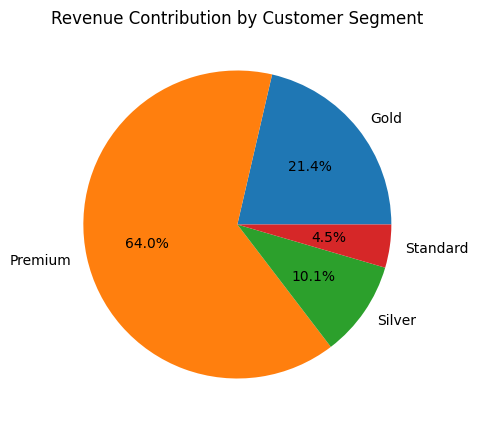

In [152]:
# Visualize Revenue Contribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.pie(

    segment_analysis['Revenue_Contribution_%'],

    labels=segment_analysis['Customer_Segment'],

    autopct='%1.1f%%'

)

plt.title(

    'Revenue Contribution by Customer Segment'

)

plt.show()

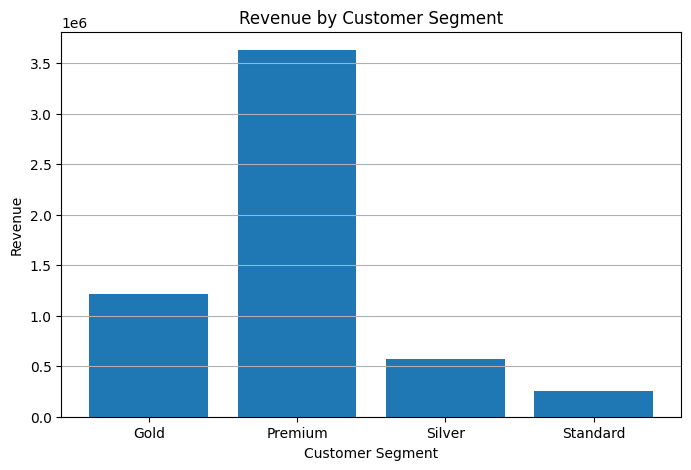

In [153]:
# Visualize Total Revenue

plt.figure(figsize=(8,5))

plt.bar(

    segment_analysis['Customer_Segment'],

    segment_analysis['Monetary']

)

plt.xlabel('Customer Segment')

plt.ylabel('Revenue')

plt.title(

    'Revenue by Customer Segment'

)

plt.grid(axis='y')

plt.show()

# **12. Cohort Analysis**

In [154]:
merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month,Customer_Type
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,4500,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01,New
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,4500,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01,New
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,4500,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,4500,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01,New


In [155]:
merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

merged_df['Year_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
)

In [156]:
# Find each customer's first purchase month

cohort = (

    merged_df

    .groupby('CustomerID')

    ['Year_Month']

    .min()

    .reset_index()

)

cohort.rename(

    columns={

        'Year_Month':'Cohort_Month'

    },

    inplace=True

)

cohort.head()

,CustomerID,Cohort_Month
0,12346,2019-09
1,12347,2019-03
2,12348,2019-06
3,12350,2019-12
4,12356,2019-09


In [157]:
# Merge cohort information

cohort_data = merged_df.merge(

    cohort,

    on='CustomerID',

    how='left'

)

cohort_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month,Customer_Type,Cohort_Month
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01,New,2019-01
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01,New,2019-01
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New,2019-01
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New,2019-01
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01,New,2019-01


In [158]:
# Calculate Cohort Index
# This represents how many months have passed since the first purchase.

cohort_data['Cohort_Index'] = (

    (cohort_data['Year_Month'].dt.year

     - cohort_data['Cohort_Month'].dt.year)

    * 12

    +

    (cohort_data['Year_Month'].dt.month

     - cohort_data['Cohort_Month'].dt.month)

)

In [159]:
# Count active customers

cohort_counts = (

    cohort_data

    .groupby(

        ['Cohort_Month',

         'Cohort_Index']

    )

    ['CustomerID']

    .nunique()

    .reset_index()

)

cohort_counts.head()

,Cohort_Month,Cohort_Index,CustomerID
0,2019-01,0,215
1,2019-01,1,13
2,2019-01,2,24
3,2019-01,3,34
4,2019-01,4,23


In [160]:
# Create Cohort Table

cohort_table = (

    cohort_counts

    .pivot(

        index='Cohort_Month',

        columns='Cohort_Index',

        values='CustomerID'

    )

)

cohort_table

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01,215.0,13.0,24.0,34.0,23.0,44.0,35.0,47.0,23.0,28.0,20.0,34.0
2019-02,96.0,7.0,9.0,16.0,17.0,22.0,19.0,15.0,12.0,11.0,16.0,NaN
2019-03,177.0,18.0,35.0,25.0,32.0,33.0,22.0,22.0,15.0,19.0,NaN,NaN
2019-04,163.0,14.0,24.0,24.0,18.0,15.0,10.0,16.0,12.0,NaN,NaN,NaN
2019-05,112.0,12.0,9.0,13.0,10.0,13.0,14.0,8.0,NaN,NaN,NaN,NaN
2019-06,137.0,20.0,22.0,12.0,11.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
2019-07,94.0,13.0,4.0,6.0,11.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,135.0,14.0,15.0,10.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,78.0,6.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
# Calculate Retention Rates
# Month 0 is the cohort size.

cohort_size = cohort_table.iloc[:,0]

retention_table = (

    cohort_table

    .divide(

        cohort_size,

        axis=0

    )

    * 100

)

retention_table.round(2)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01,100.0,6.05,11.16,15.81,10.70,20.47,16.28,21.86,10.70,13.02,9.30,15.81
2019-02,100.0,7.29,9.38,16.67,17.71,22.92,19.79,15.62,12.50,11.46,16.67,NaN
2019-03,100.0,10.17,19.77,14.12,18.08,18.64,12.43,12.43,8.47,10.73,NaN,NaN
2019-04,100.0,8.59,14.72,14.72,11.04,9.20,6.13,9.82,7.36,NaN,NaN,NaN
2019-05,100.0,10.71,8.04,11.61,8.93,11.61,12.50,7.14,NaN,NaN,NaN,NaN
2019-06,100.0,14.60,16.06,8.76,8.03,10.22,8.03,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,13.83,4.26,6.38,11.70,9.57,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,10.37,11.11,7.41,5.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,7.69,3.85,2.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
# Calculate Overall Cohort Performance

cohort_performance = (

    retention_table

    .iloc[:,1:]

    .mean(axis=1)

    .reset_index()

)

cohort_performance.columns = [

    'Cohort_Month',

    'Average_Retention'

]

cohort_performance.round(2)

,Cohort_Month,Average_Retention
0,2019-01,13.74
1,2019-02,15.00
2,2019-03,13.87
3,2019-04,10.20
4,2019-05,10.08
5,2019-06,10.95
6,2019-07,9.15
7,2019-08,8.70
8,2019-09,4.70
9,2019-10,5.75


In [163]:
# Identify Strongest and Weakest Cohorts

best_cohort = cohort_performance.loc[

    cohort_performance['Average_Retention']

    .idxmax()

]

worst_cohort = cohort_performance.loc[

    cohort_performance['Average_Retention']

    .idxmin()

]

print(

    f"Highest Retention Cohort: "

    f"{best_cohort['Cohort_Month']} "

    f"({best_cohort['Average_Retention']:.2f}%)"

)

print(

    f"Lowest Retention Cohort: "

    f"{worst_cohort['Cohort_Month']} "

    f"({worst_cohort['Average_Retention']:.2f}%)"

)

Highest Retention Cohort: 2019-02 (15.00%)
Lowest Retention Cohort: 2019-09 (4.70%)


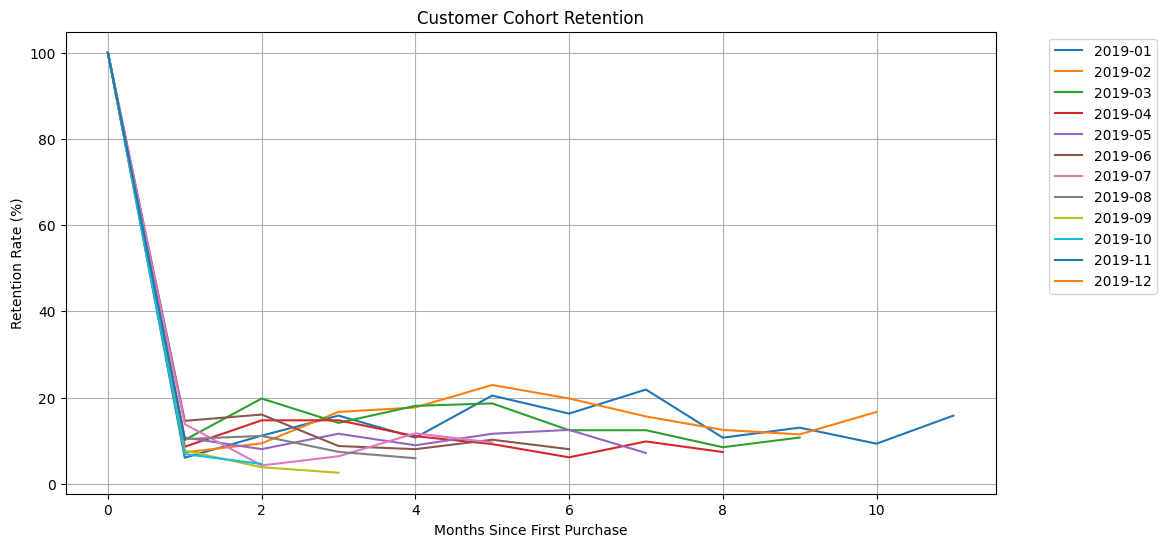

In [164]:
# Visualize Retention

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for cohort in retention_table.index:

    plt.plot(

        retention_table.columns,

        retention_table.loc[cohort],

        label=str(cohort)

    )

plt.xlabel('Months Since First Purchase')

plt.ylabel('Retention Rate (%)')

plt.title('Customer Cohort Retention')

plt.legend(

    bbox_to_anchor=(1.05,1),

    loc='upper left'

)

plt.grid(True)

plt.show()

# **13. Analyze the lifetime value of customers acquired in different months**

In [165]:
# Create Acquisition Month

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

customer_acquisition = (

    merged_df

    .groupby('CustomerID')

    ['Transaction_Date']

    .min()

    .reset_index()

)

customer_acquisition.rename(

    columns={

        'Transaction_Date':'First_Purchase_Date'

    },

    inplace=True

)

customer_acquisition['Acquisition_Month'] = (

    customer_acquisition['First_Purchase_Date']

    .dt.to_period('M')

)

In [166]:
# Merge Acquisition Month

ltv_df = merged_df.merge(

    customer_acquisition[
        ['CustomerID',

         'Acquisition_Month']

    ],

    on='CustomerID',

    how='left'

)

ltv_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value,Year_Month,First_Purchase_Month,Customer_Type,Acquisition_Month
0,12583,16692,2019-01-01,GGOEAFKQ020599,Android Sticker Sheet Ultra Removable,Office,1,2.47,102.79,Used,...,2424.5,January,2.47,2.47,2.7170,105.5070,2019-01,2019-01,New,2019-01
1,12583,16692,2019-01-01,GGOEGDHC015299,23 oz Wide Mouth Sport Bottle,Drinkware,26,8.72,102.79,Clicked,...,2424.5,January,226.72,226.72,267.5296,370.3196,2019-01,2019-01,New,2019-01
2,12583,16692,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,1.64,102.79,Clicked,...,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New,2019-01
3,12583,16692,2019-01-01,GGOEYFKQ020699,YouTube Custom Decals,Office,1,1.64,102.79,Clicked,...,2424.5,January,1.64,1.64,1.8040,104.5940,2019-01,2019-01,New,2019-01
4,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,...,2424.5,January,206.18,206.18,216.4890,319.2790,2019-01,2019-01,New,2019-01


In [167]:
# Calculate Customer Lifetime Value (LTV)

customer_ltv = (

    ltv_df

    .groupby(

        ['CustomerID',

         'Acquisition_Month']

    )

    .agg(

        Lifetime_Revenue=(

            'Invoice_Value',

            'sum'

        ),

        Total_Transactions=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

customer_ltv.head()

,CustomerID,Acquisition_Month,Lifetime_Revenue,Total_Transactions
0,12346,2019-09,185.6882,1
1,12347,2019-03,16567.9470,31
2,12348,2019-06,1842.8708,8
3,12350,2019-12,1636.2142,11
4,12356,2019-09,2231.7198,13


In [168]:
# Calculate LTV by Acquisition Month

monthly_ltv = (

    customer_ltv

    .groupby(

        'Acquisition_Month'

    )

    .agg(

        Average_LTV=(

            'Lifetime_Revenue',

            'mean'

        ),

        Total_LTV=(

            'Lifetime_Revenue',

            'sum'

        ),

        Customer_Count=(

            'CustomerID',

            'nunique'

        )

    )

    .reset_index()

)

monthly_ltv.round(2)

,Acquisition_Month,Average_LTV,Total_LTV,Customer_Count
0,2019-01,5967.25,1282958.35,215
1,2019-02,6997.77,671785.67,96
2,2019-03,4644.13,822011.68,177
3,2019-04,3336.22,543803.34,163
4,2019-05,3282.04,367588.17,112
5,2019-06,2630.14,360328.50,137
6,2019-07,3092.13,290660.47,94
7,2019-08,2378.75,321130.80,135
8,2019-09,2395.15,186821.98,78
9,2019-10,3218.04,279969.55,87


In [169]:
# Identify Best and Worst Months

highest_ltv = monthly_ltv.loc[

    monthly_ltv['Average_LTV']

    .idxmax()

]

lowest_ltv = monthly_ltv.loc[

    monthly_ltv['Average_LTV']

    .idxmin()

]

print(

    f"Highest LTV Month: "

    f"{highest_ltv['Acquisition_Month']} "

    f"(₹{highest_ltv['Average_LTV']:,.2f})"

)

print(

    f"Lowest LTV Month: "

    f"{lowest_ltv['Acquisition_Month']} "

    f"(₹{lowest_ltv['Average_LTV']:,.2f})"

)

Highest LTV Month: 2019-02 (₹6,997.77)
Lowest LTV Month: 2019-08 (₹2,378.75)


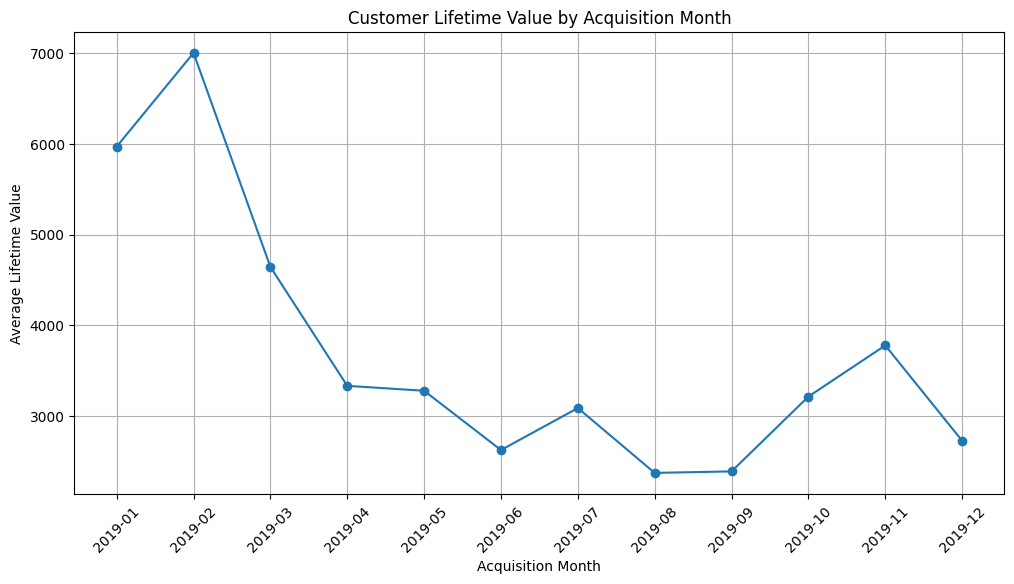

In [170]:
# Visualize LTV Trends

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    monthly_ltv['Acquisition_Month']

    .astype(str),

    monthly_ltv['Average_LTV'],

    marker='o'

)

plt.xticks(rotation=45)

plt.xlabel('Acquisition Month')

plt.ylabel('Average Lifetime Value')

plt.title(

    'Customer Lifetime Value by Acquisition Month'

)

plt.grid(True)

plt.show()

In [171]:
# Calculate Revenue Contribution

monthly_ltv['Revenue_Contribution_%'] = (

    monthly_ltv['Total_LTV']

    * 100

    /

    monthly_ltv['Total_LTV']

    .sum()

)

monthly_ltv.round(2)

,Acquisition_Month,Average_LTV,Total_LTV,Customer_Count,Revenue_Contribution_%
0,2019-01,5967.25,1282958.35,215,22.61
1,2019-02,6997.77,671785.67,96,11.84
2,2019-03,4644.13,822011.68,177,14.49
3,2019-04,3336.22,543803.34,163,9.58
4,2019-05,3282.04,367588.17,112,6.48
5,2019-06,2630.14,360328.50,137,6.35
6,2019-07,3092.13,290660.47,94,5.12
7,2019-08,2378.75,321130.80,135,5.66
8,2019-09,2395.15,186821.98,78,3.29
9,2019-10,3218.04,279969.55,87,4.93


# **14. Coupon Usage vs Average Transaction Value (Hypothesis Testing)**

In [172]:
# Check Coupon Column Values

merged_df['Coupon_Status'].value_counts()

,count
Coupon_Status,
Clicked,26926
Used,17904
Not Used,8094


In [173]:
# Create the Two Groups

coupon_group = merged_df.loc[

    merged_df['Coupon_Status'] == 'Used',

    'Invoice_Value'

]

non_coupon_group = merged_df.loc[

    merged_df['Coupon_Status'] == 'Not Used',

    'Invoice_Value'

]

In [174]:
# Compare Average Transaction Values

print(

    'Coupon Users Average:',

    coupon_group.mean()

)

print(

    'Non-Coupon Users Average:',

    non_coupon_group.mean()

)

Coupon Users Average: 105.99495118744416
Non-Coupon Users Average: 109.57504869038793


In [175]:
# Perform Welch's T-Test

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(

    coupon_group,

    non_coupon_group,

    equal_var=False

)

print(

    'T-statistic:',

    round(t_statistic,3)

)

print(

    'P-value:',

    round(p_value,5)

)

T-statistic: -1.4
P-value: 0.16166


In [176]:
# Interpret the Result

alpha = 0.05

if p_value < alpha:

    print(

        'Reject H0'

    )

    print(

        'There is a significant difference.'

    )

else:

    print(

        'Fail to reject H0'

    )

    print(

        'No significant difference.'

    )

Fail to reject H0
No significant difference.


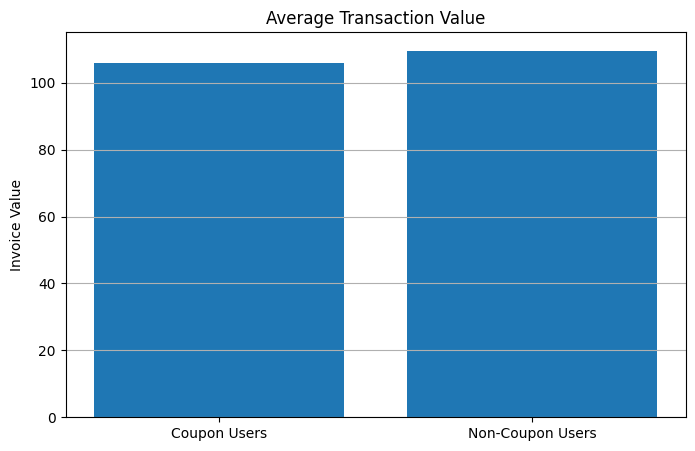

In [177]:
# Visualize the Difference

import matplotlib.pyplot as plt

avg_values = [

    coupon_group.mean(),

    non_coupon_group.mean()

]

labels = [

    'Coupon Users',

    'Non-Coupon Users'

]

plt.figure(figsize=(8,5))

plt.bar(

    labels,

    avg_values

)

plt.title(

    'Average Transaction Value'

)

plt.ylabel(

    'Invoice Value'

)

plt.grid(axis='y')

plt.show()

In [178]:
# Create a Summary Table

comparison = pd.DataFrame({

    'Group': [

        'Coupon Users',

        'Non-Coupon Users'

    ],

    'Average_Transaction_Value': [

        coupon_group.mean(),

        non_coupon_group.mean()

    ],

    'Transaction_Count': [

        coupon_group.count(),

        non_coupon_group.count()

    ]

})

comparison.round(2)

,Group,Average_Transaction_Value,Transaction_Count
0,Coupon Users,105.99,17904
1,Non-Coupon Users,109.58,8094


In [180]:
print(merged_df.columns.tolist())

['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'Month_x', 'Gender', 'Location', 'Tenure_Months', 'GST', 'Coupon_Code', 'Discount_pct', 'Offline_Spend', 'Online_Spend', 'Month_y', 'Base_Amount', 'Discounted_Amount', 'Taxed_Amount', 'Invoice_Value', 'Year_Month', 'First_Purchase_Month', 'Customer_Type']


# **15. Analyze differences in purchase behavior**

In [187]:
# Purchase behavior metrics:
#   Order Frequency → Number of orders
#   Order Value → Average Invoice_Value

In [182]:
if p_value < 0.05:

    print('Significant difference across locations.')

else:

    print('No significant difference across locations.')

Significant difference across locations.


In [183]:
# Delivery Charge Tier Analysis


In [186]:
# Analyze by Location
# Revenue by Location

location_summary = (

    merged_df

    .groupby('Location')

    .agg(

        Avg_Order_Value=(

            'Invoice_Value',

            'mean'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

location_summary.round(2)

,Location,Avg_Order_Value,Order_Count
0,California,108.63,7890
1,Chicago,107.47,9090
2,New Jersey,109.31,2269
3,New York,102.26,5499
4,Washington DC,113.72,1410


In [188]:
# Use Location + Delivery Charges
# Location Analysis

from scipy.stats import f_oneway

location_groups = []

for loc in merged_df['Location'].dropna().unique():

    location_groups.append(

        merged_df.loc[
            merged_df['Location']==loc,
            'Invoice_Value'
        ]

    )

f_stat, p_value = f_oneway(*location_groups)

print('P-value:', round(p_value,5))

P-value: 0.0094


# **Part 3: Analyze by Delivery Charge Tiers**

In [189]:
# Create Delivery Charge Groups
# Create tiers:

merged_df['Delivery_Tier'] = pd.qcut(

    merged_df['Delivery_Charges'],

    q=3,

    labels=['Low','Medium','High']

)

In [190]:
# Analyze Delivery Tiers

delivery_summary = (

    merged_df

    .groupby('Delivery_Tier')

    .agg(

        Avg_Order_Value=(

            'Invoice_Value',

            'mean'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

delivery_summary.round(2)

/tmp/ipykernel_23736/890533666.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Delivery_Tier')


,Delivery_Tier,Avg_Order_Value,Order_Count
0,Low,90.23,12720
1,Medium,119.10,8725
2,High,133.85,3616


In [191]:
# Perform ANOVA:

delivery_groups = []

for tier in merged_df['Delivery_Tier'].dropna().unique():

    delivery_groups.append(

        merged_df.loc[
            merged_df['Delivery_Tier']==tier,
            'Invoice_Value'
        ]

    )

f_stat, p_value = f_oneway(*delivery_groups)

print('P-value:', round(p_value,5))

P-value: 0.0


# **16. Does customer tenure impact purchase frequency?**

In [193]:
# Calculate Customer Tenure

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

reference_date = merged_df['Transaction_Date'].max()

customer_tenure = (

    merged_df

    .groupby('CustomerID')

    .agg(

        First_Purchase=(

            'Transaction_Date',

            'min'

        ),

        Purchase_Frequency=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

customer_tenure['Tenure_Months'] = (

    (

        reference_date

        - customer_tenure['First_Purchase']

    )

    .dt.days

    / 30

).round()

customer_tenure.head()

,CustomerID,First_Purchase,Purchase_Frequency,Tenure_Months
0,12346,2019-09-15,1,4.0
1,12347,2019-03-24,31,9.0
2,12348,2019-06-22,8,6.0
3,12350,2019-12-14,11,1.0
4,12356,2019-09-15,13,4.0


In [194]:
# Normalize Purchase Frequency

customer_tenure['Frequency_Per_Month'] = (

    customer_tenure['Purchase_Frequency']

    /

    customer_tenure['Tenure_Months']

)

customer_tenure.head()

,CustomerID,First_Purchase,Purchase_Frequency,Tenure_Months,Frequency_Per_Month
0,12346,2019-09-15,1,4.0,0.250000
1,12347,2019-03-24,31,9.0,3.444444
2,12348,2019-06-22,8,6.0,1.333333
3,12350,2019-12-14,11,1.0,11.000000
4,12356,2019-09-15,13,4.0,3.250000


In [196]:
customer_tenure['Frequency_Per_Month'] = (

    customer_tenure['Frequency_Per_Month']

    .replace(

        [np.inf, -np.inf],

        np.nan

    )

)

customer_tenure.dropna(inplace=True)
customer_tenure.head()

,CustomerID,First_Purchase,Purchase_Frequency,Tenure_Months,Frequency_Per_Month
0,12346,2019-09-15,1,4.0,0.250000
1,12347,2019-03-24,31,9.0,3.444444
2,12348,2019-06-22,8,6.0,1.333333
3,12350,2019-12-14,11,1.0,11.000000
4,12356,2019-09-15,13,4.0,3.250000


In [197]:
# Create Tenure Groups

customer_tenure['Tenure_Group'] = pd.qcut(

    customer_tenure['Tenure_Months'],

    q=3,

    labels=[

        'Low',

        'Medium',

        'High'

    ]

)

customer_tenure.head()

,CustomerID,First_Purchase,Purchase_Frequency,Tenure_Months,Frequency_Per_Month,Tenure_Group
0,12346,2019-09-15,1,4.0,0.250000,Low
1,12347,2019-03-24,31,9.0,3.444444,Medium
2,12348,2019-06-22,8,6.0,1.333333,Low
3,12350,2019-12-14,11,1.0,11.000000,Low
4,12356,2019-09-15,13,4.0,3.250000,Low


In [198]:
# Analyze Purchase Frequency

tenure_summary = (

    customer_tenure

    .groupby('Tenure_Group')

    .agg(

        Avg_Frequency=(

            'Purchase_Frequency',

            'mean'

        ),

        Avg_Frequency_Per_Month=(

            'Frequency_Per_Month',

            'mean'

        )

    )

    .reset_index()

)

tenure_summary.round(2)

/tmp/ipykernel_23736/3658616427.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Tenure_Group')


,Tenure_Group,Avg_Frequency,Avg_Frequency_Per_Month
0,Low,13.65,5.29
1,Medium,16.44,2.03
2,High,26.40,2.40


In [199]:
# Perform ANOVA Test
# Since we have 3 groups, use One-Way ANOVA.

from scipy.stats import f_oneway

low = customer_tenure.loc[

    customer_tenure['Tenure_Group']=='Low',

    'Purchase_Frequency'

]

medium = customer_tenure.loc[

    customer_tenure['Tenure_Group']=='Medium',

    'Purchase_Frequency'

]

high = customer_tenure.loc[

    customer_tenure['Tenure_Group']=='High',

    'Purchase_Frequency'

]

f_stat, p_value = f_oneway(

    low,

    medium,

    high

)

print(

    'F-statistic:',

    round(f_stat,3)

)

print(

    'P-value:',

    round(p_value,5)

)

F-statistic: 34.37
P-value: 0.0


In [200]:
# Interpret the Result

if p_value < 0.05:

    print(

        'Significant relationship exists.'

    )

else:

    print(

        'No significant relationship exists.'

    )

Significant relationship exists.


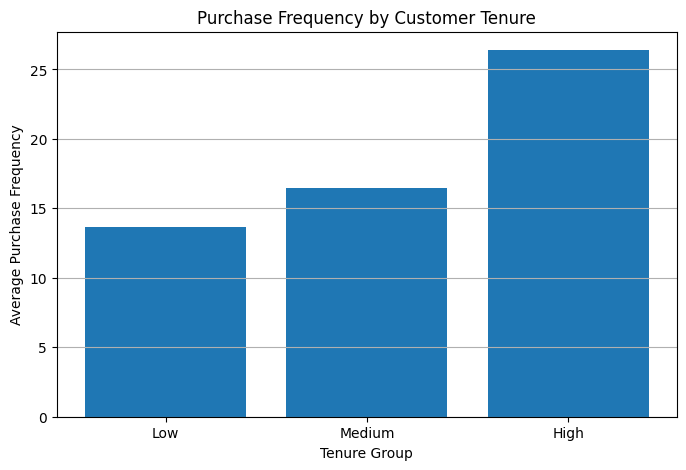

In [201]:
# Visualize

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    tenure_summary['Tenure_Group'],

    tenure_summary['Avg_Frequency']

)

plt.xlabel('Tenure Group')

plt.ylabel('Average Purchase Frequency')

plt.title(

    'Purchase Frequency by Customer Tenure'

)

plt.grid(axis='y')

plt.show()

# **17. Delivery Charges vs Order Behavior**

In [202]:
merged_df['Delivery_Tier']

,Delivery_Tier
0,High
1,High
2,High
3,High
4,High
...,...
52919,Medium
52920,Medium
52921,Medium
52922,Medium


In [203]:
merged_df['Delivery_Tier'].value_counts()

,count
Delivery_Tier,
Low,26963
Medium,15862
High,10099


In [204]:
# Analyze Order Behavior

delivery_summary = (

    merged_df

    .groupby('Delivery_Tier')

    .agg(

        Avg_Quantity=(

            'Quantity',

            'mean'

        ),

        Avg_Revenue=(

            'Invoice_Value',

            'mean'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

delivery_summary.round(2)

/tmp/ipykernel_23736/2736805077.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Delivery_Tier')


,Delivery_Tier,Avg_Quantity,Avg_Revenue,Order_Count
0,Low,2.97,90.23,12720
1,Medium,3.43,119.10,8725
2,High,10.25,133.85,3616


In [205]:
# Correlation Analysis
# Delivery Charges vs Quantity

corr_quantity = merged_df['Delivery_Charges'].corr(

    merged_df['Quantity']

)

print(

    'Correlation (Charges vs Quantity):',

    round(corr_quantity,3)

)

Correlation (Charges vs Quantity): 0.191


In [206]:
# Delivery Charges vs Revenue

corr_revenue = merged_df['Delivery_Charges'].corr(

    merged_df['Invoice_Value']

)

print(

    'Correlation (Charges vs Revenue):',

    round(corr_revenue,3)

)


Correlation (Charges vs Revenue): 0.177


In [207]:
# Statistical Test (ANOVA)

from scipy.stats import f_oneway

low = merged_df.loc[

    merged_df['Delivery_Tier']=='Low',

    'Quantity'

]

medium = merged_df.loc[

    merged_df['Delivery_Tier']=='Medium',

    'Quantity'

]

high = merged_df.loc[

    merged_df['Delivery_Tier']=='High',

    'Quantity'

]

f_stat, p_value = f_oneway(

    low,

    medium,

    high

)

print(

    'F-statistic:',

    round(f_stat,3)

)

print(

    'P-value:',

    round(p_value,5)

)

F-statistic: 524.271
P-value: 0.0


In [208]:
# Interpret

if p_value < 0.05:

    print(

        'Significant difference exists.'

    )

else:

    print(

        'No significant difference exists.'

    )

Significant difference exists.


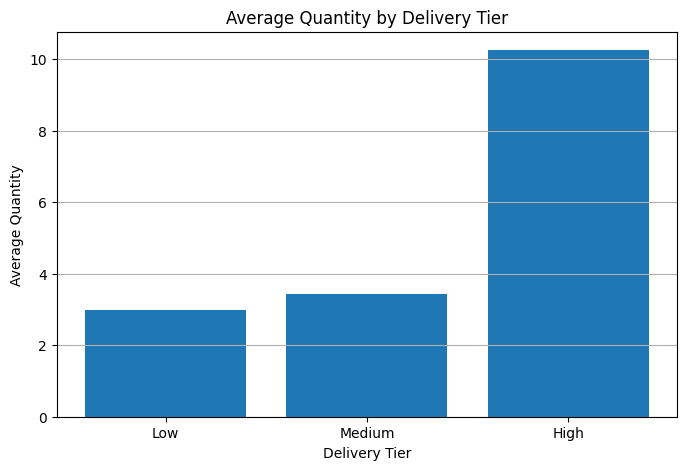

In [209]:
# Visualize Quantity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    delivery_summary['Delivery_Tier'],

    delivery_summary['Avg_Quantity']

)

plt.xlabel('Delivery Tier')

plt.ylabel('Average Quantity')

plt.title(

    'Average Quantity by Delivery Tier'

)

plt.grid(axis='y')

plt.show()



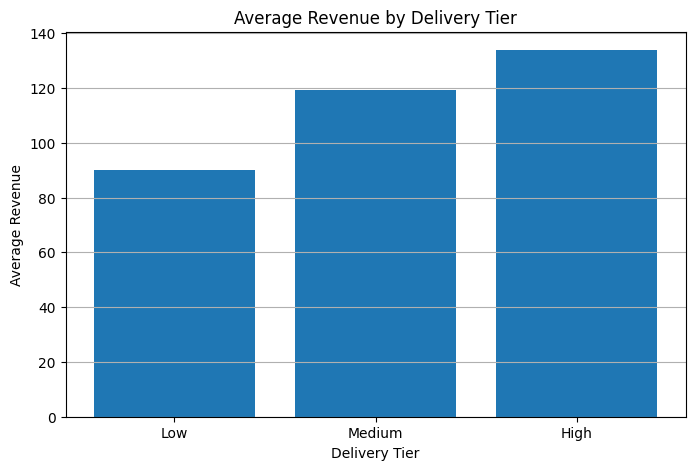

In [210]:
# Visualize Revenue

plt.figure(figsize=(8,5))

plt.bar(

    delivery_summary['Delivery_Tier'],

    delivery_summary['Avg_Revenue']

)

plt.xlabel('Delivery Tier')

plt.ylabel('Average Revenue')

plt.title(

    'Average Revenue by Delivery Tier'

)

plt.grid(axis='y')

plt.show()

#**18 Evaluate how taxes and delivery charges influence customer spending behavior**

In [211]:
# Taxes and Delivery Charges vs Customer Spending Behavior
merged_df['Delivery_Tier'].value_counts()

,count
Delivery_Tier,
Low,26963
Medium,15862
High,10099


In [213]:
# Analyze Spending by Delivery Tier

delivery_analysis = (

    merged_df

    .groupby('Delivery_Tier')

    .agg(

        Avg_Invoice_Value=(

            'Invoice_Value',

            'mean'

        ),

        Avg_Quantity=(

            'Quantity',

            'mean'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

delivery_analysis.round(2)

/tmp/ipykernel_23736/3739803860.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Delivery_Tier')


,Delivery_Tier,Avg_Invoice_Value,Avg_Quantity,Order_Count
0,Low,90.23,2.97,12720
1,Medium,119.10,3.43,8725
2,High,133.85,10.25,3616


In [214]:
# Analyze Tax Impact

tax_analysis = (

    merged_df

    .groupby('GST')

    .agg(

        Avg_Invoice_Value=(

            'Invoice_Value',

            'mean'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        )

    )

    .reset_index()

)

tax_analysis.round(2)

,GST,Avg_Invoice_Value,Order_Count
0,0.05,188.41,3585
1,0.10,158.81,15510
2,0.12,58.52,122
3,0.18,54.89,10880


In [215]:
# If GST has many unique values, categorize it.

merged_df['GST_Tier'] = pd.cut(

    merged_df['GST'],

    bins=3,

    labels=[

        'Low',

        'Medium',

        'High'

    ]

)

In [216]:
gst_summary = (

    merged_df

    .groupby('GST_Tier')

    .agg(

        Avg_Invoice_Value=(

            'Invoice_Value',

            'mean'

        )

    )

    .reset_index()

)

gst_summary.round(2)

/tmp/ipykernel_23736/1949153974.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('GST_Tier')


,GST_Tier,Avg_Invoice_Value
0,Low,188.41
1,Medium,158.24
2,High,54.89


In [217]:
# Correlation Analysis
# GST vs Invoice Value

gst_corr = merged_df['GST'].corr(

    merged_df['Invoice_Value']

)

print(

    'GST Correlation:',

    round(gst_corr,3)

)


GST Correlation: -0.298


In [218]:
# Delivery Charges vs Invoice Value

delivery_corr = merged_df['Delivery_Charges'].corr(

    merged_df['Invoice_Value']

)

print(

    'Delivery Correlation:',

    round(delivery_corr,3)

)

Delivery Correlation: 0.177


In [220]:
# Interpretation:
# Correlation	Meaning
#   > 0	Positive relationship
#   < 0	Negative relationship
#   ≈ 0	Weak relationship

In [221]:
# ANOVA Test

from scipy.stats import f_oneway

low = merged_df.loc[

    merged_df['Delivery_Tier']=='Low',

    'Invoice_Value'

]

medium = merged_df.loc[

    merged_df['Delivery_Tier']=='Medium',

    'Invoice_Value'

]

high = merged_df.loc[

    merged_df['Delivery_Tier']=='High',

    'Invoice_Value'

]

f_stat, p_value = f_oneway(

    low,

    medium,

    high

)

print(

    'F-statistic:',

    round(f_stat,3)

)

print(

    'P-value:',

    round(p_value,5)

)

F-statistic: 262.688
P-value: 0.0


In [222]:
# Interpret

if p_value < 0.05:

    print(

        'Significant difference exists.'

    )

else:

    print(

        'No significant difference.'

    )

Significant difference exists.


In [223]:
# Create Total Additional Charges

merged_df['GST_Amount'] = (

    merged_df['Invoice_Value']

    * merged_df['GST']

)

In [225]:
merged_df['GST']

,GST
0,0.10
1,0.18
2,0.10
3,0.10
4,0.05
...,...
52919,0.10
52920,0.10
52921,0.18
52922,0.18


In [226]:
merged_df['Extra_Charges'] = (

    merged_df['GST_Amount']

    +

    merged_df['Delivery_Charges']

)

In [227]:
merged_df['GST_Amount']

,GST_Amount
0,10.550700
1,66.657528
2,10.459400
3,10.459400
4,15.963950
...,...
52919,17.356800
52920,44.936000
52921,1.907028
52922,4.632120


In [228]:
extra_charge_analysis = (

    merged_df

    .agg(

        Avg_Extra_Charges=(

            'Extra_Charges',

            'mean'

        ),

        Avg_Invoice_Value=(

            'Invoice_Value',

            'mean'

        )

    )

)

extra_charge_analysis

,Extra_Charges,Invoice_Value
Avg_Extra_Charges,22.771637,NaN
Avg_Invoice_Value,NaN,107.205537


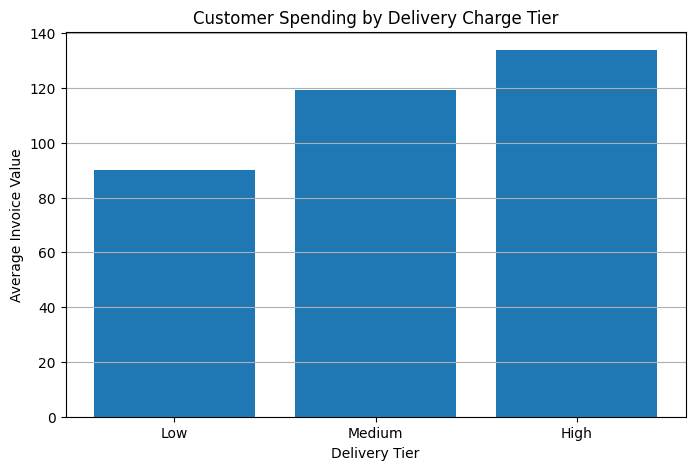

In [229]:
# Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    delivery_analysis['Delivery_Tier'],

    delivery_analysis['Avg_Invoice_Value']

)

plt.xlabel('Delivery Tier')

plt.ylabel('Average Invoice Value')

plt.title(

    'Customer Spending by Delivery Charge Tier'

)

plt.grid(axis='y')

plt.show()

# **19. Identify Seasonal Trends in Sales by Category and Location**

In [230]:
merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

merged_df['Month'] = (
    merged_df['Transaction_Date']
    .dt.month_name()
)

merged_df['Month_Number'] = (
    merged_df['Transaction_Date']
    .dt.month
)

In [231]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CustomerID            52924 non-null  object        
 1   Transaction_ID        52924 non-null  object        
 2   Transaction_Date      52924 non-null  datetime64[ns]
 3   Product_SKU           52924 non-null  object        
 4   Product_Description   52924 non-null  object        
 5   Product_Category      52924 non-null  object        
 6   Quantity              52924 non-null  int64         
 7   Avg_Price             52924 non-null  float64       
 8   Delivery_Charges      52924 non-null  float64       
 9   Coupon_Status         52924 non-null  object        
 10  Month_x               52924 non-null  object        
 11  Gender                52924 non-null  object        
 12  Location              52924 non-null  object        
 13  Tenure_Months   

In [232]:
# Monthly Revenue Trend

monthly_sales = (

    merged_df

    .groupby(

        ['Month_Number','Month']

    )

    ['Invoice_Value']

    .sum()

    .reset_index()

    .sort_values(

        'Month_Number'

    )

)

monthly_sales

,Month_Number,Month,Invoice_Value
0,1,January,508514.75510
1,2,February,396865.65700
2,3,March,453205.06730
3,4,April,492559.70690
4,5,May,318556.30056
5,6,June,397002.93390
6,7,July,465289.01890
7,8,August,506936.61000
8,9,September,440822.42580
9,10,October,495627.71850


In [233]:
# Sales by Product Category and Month

category_sales = (

    merged_df

    .groupby(

        ['Month',

         'Product_Category']

    )

    ['Invoice_Value']

    .sum()

    .reset_index()

)

category_sales.head()

,Month,Product_Category,Invoice_Value
0,April,Accessories,208.6560
1,April,Android,56.9780
2,April,Apparel,117853.2752
3,April,Backpacks,1292.9440
4,April,Bags,15183.6354


In [234]:
# Create a Pivot Table

category_pivot = (

    category_sales

    .pivot(

        index='Month',

        columns='Product_Category',

        values='Invoice_Value'

    )

)

category_pivot.fillna(0)

Product_Category,Accessories,Android,Apparel,Backpacks,Bags,Bottles,Drinkware,Fun,Gift Cards,Google,Headgear,Housewares,Lifestyle,More Bags,Nest,Nest-Canada,Nest-USA,Notebooks & Journals,Office,Waze
Month,,,,,,,,,,,,,,,,,,,,
April,208.6560,56.978,117853.2752,1292.944,15183.63540,769.5700,35587.7074,2972.6102,761.2500,1241.062,13516.4800,189.1900,13638.67580,518.1940,0.000,6418.000,207335.190,25428.3255,48527.3080,1060.65540
August,422.2760,152.143,87439.2604,1708.515,21666.23800,767.3035,32526.1868,439.9752,787.5000,312.905,23827.0930,1268.1700,13819.19200,0.0000,22310.720,5653.800,223630.490,32468.4255,36616.6590,1119.75760
December,1243.6270,0.000,68138.5692,0.000,11825.71020,0.0000,13689.7852,0.0000,840.1365,0.000,1728.8820,0.0000,3029.13620,0.0000,158403.306,6046.619,320387.352,1093.7080,24045.2160,1192.85720
February,0.0000,28.489,58054.1562,662.214,25352.44900,586.7565,22295.9096,513.5164,420.0000,1843.491,5448.0240,187.1388,13698.04720,546.6716,0.000,4566.550,223079.249,6918.6235,31931.7210,732.65020
January,63.2270,107.664,60725.2166,336.029,15928.85340,1109.7950,21638.7962,450.3328,297.8745,1314.954,2922.8920,1689.2776,10897.20580,1694.7088,0.000,10967.031,323336.928,8123.4970,45840.7100,1069.76240
July,2165.0660,175.501,95105.6900,853.892,16063.69180,1638.2430,17703.7184,1390.7080,525.0000,1953.536,3204.0225,1635.0920,15418.76420,0.0000,0.000,8784.640,237844.860,26305.4610,34099.3960,421.73700
June,284.4930,243.090,68638.2918,366.676,16586.23660,828.0375,23473.5072,970.4976,1260.0000,1367.905,1851.3905,530.3400,9841.15840,0.0000,0.000,10549.750,222574.610,5833.2965,30930.5220,873.13180
March,72.4890,253.813,86736.4036,802.213,20163.23700,737.1690,32459.8160,1015.0194,393.7500,3342.675,4042.0695,1015.6000,12957.65940,721.3250,0.000,8619.000,227878.150,5955.2220,44483.5220,1555.93440
May,174.0332,110.916,71011.2696,1702.996,11111.89256,1334.5956,18910.1120,930.8428,1113.0000,1792.279,3114.9124,584.0640,7814.26144,492.2134,0.000,3524.730,159457.900,5832.8392,28713.4296,830.01376


In [235]:
# Analyze Sales by Location

location_sales = (

    merged_df

    .groupby(

        ['Month',

         'Location']

    )

    ['Invoice_Value']

    .sum()

    .reset_index()

)

location_sales.head()

,Month,Location,Invoice_Value
0,April,California,150148.6301
1,April,Chicago,184379.2636
2,April,New Jersey,54735.2791
3,April,New York,79836.1274
4,April,Washington DC,23460.4067


In [236]:
# Create Location Pivot Table

location_pivot = (

    location_sales

    .pivot(

        index='Month',

        columns='Location',

        values='Invoice_Value'

    )

)

location_pivot.fillna(0)

Location,California,Chicago,New Jersey,New York,Washington DC
Month,,,,,
April,150148.63010,184379.26360,54735.27910,79836.12740,23460.4067
August,149393.48490,200823.17730,28699.17570,103577.86440,24442.9077
December,214457.57310,224567.29810,61454.65150,87687.46120,23497.9206
February,114922.69460,143870.14620,37143.52830,56033.63300,44895.6549
January,193002.98130,134915.98640,38876.11300,99363.39950,42356.2749
July,149194.43980,162581.46090,28117.41240,101801.49960,23594.2062
June,123781.02510,124490.35700,48932.93960,84675.35980,15123.2524
March,127616.50890,155565.23230,25307.43250,123455.92700,21259.9666
May,90442.58244,114245.72996,28634.33704,79045.13272,6188.5184


In [237]:
# Identify Peak and Off-Peak Months
# Peak Month

peak_month = monthly_sales.loc[

    monthly_sales['Invoice_Value']

    .idxmax()

]

print(

    'Peak Month:'

)

print(peak_month)

Peak Month:
Month_Number              12
Month               December
Invoice_Value    611664.9045
Name: 11, dtype: object


In [238]:
# Off-Peak Month

off_peak_month = monthly_sales.loc[

    monthly_sales['Invoice_Value']

    .idxmin()

]

print(

    'Off-Peak Month:'

)

print(off_peak_month)

Off-Peak Month:
Month_Number                5
Month                     May
Invoice_Value    318556.30056
Name: 4, dtype: object


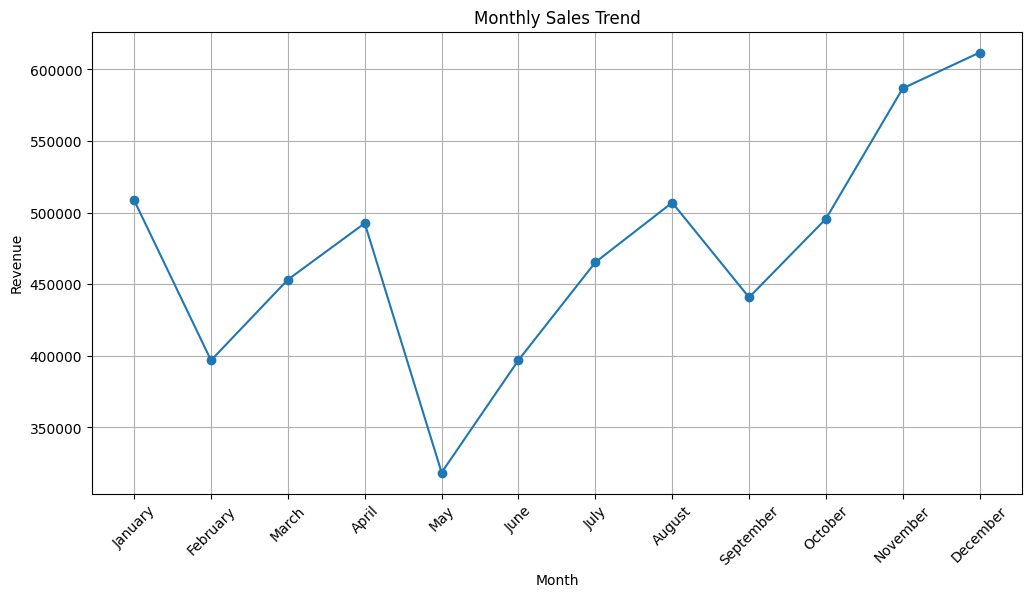

In [239]:
# Visualize Monthly Sales

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    monthly_sales['Month'],

    monthly_sales['Invoice_Value'],

    marker='o'

)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.title(

    'Monthly Sales Trend'

)

plt.grid(True)

plt.show()

<Figure size 1200x600 with 0 Axes>

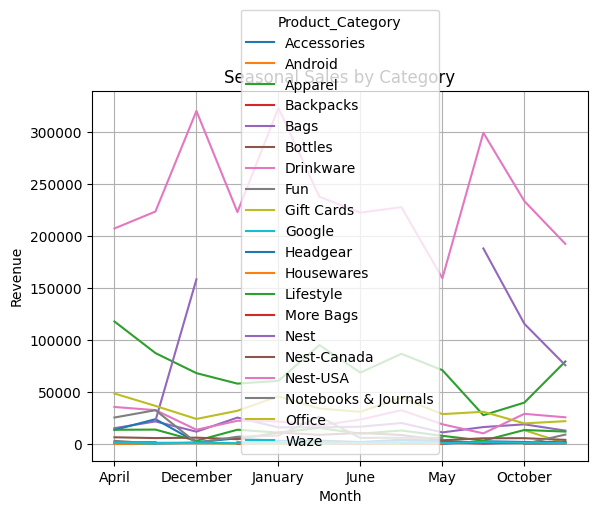

In [240]:
# Visualize Category Seasonality

plt.figure(figsize=(12,6))

category_pivot.plot()

plt.title(

    'Seasonal Sales by Category'

)

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.grid(True)

plt.show()

<Figure size 1200x600 with 0 Axes>

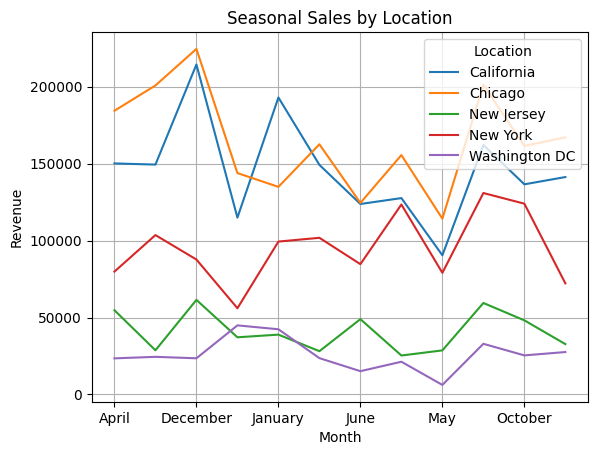

In [241]:
# Visualize Location Seasonality

plt.figure(figsize=(12,6))

location_pivot.plot()

plt.title(

    'Seasonal Sales by Location'

)

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.grid(True)

plt.show()

# **20. Analyze Daily Sales Trends**

In [242]:
# Create Day Columns

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

merged_df['Day_Name'] = (

    merged_df['Transaction_Date']

    .dt.day_name()

)

merged_df['Day_Number'] = (

    merged_df['Transaction_Date']

    .dt.dayofweek

)

In [243]:
# Calculate Daily Sales Metrics

daily_sales = (

    merged_df

    .groupby(

        ['Day_Number','Day_Name']

    )

    .agg(

        Revenue=(

            'Invoice_Value',

            'sum'

        ),

        Order_Count=(

            'Transaction_ID',

            'nunique'

        ),

        Avg_Order_Value=(

            'Invoice_Value',

            'mean'

        ),

        Quantity_Sold=(

            'Quantity',

            'sum'

        )

    )

    .reset_index()

    .sort_values(

        'Day_Number'

    )

)

daily_sales.round(2)

,Day_Number,Day_Name,Revenue,Order_Count,Avg_Order_Value,Quantity_Sold
0,0,Monday,434269.83,2130,97.28,11983
1,1,Tuesday,474374.02,2315,102.88,11317
2,2,Wednesday,1005051.31,4378,113.09,39797
3,3,Thursday,1016384.15,4278,112.93,44482
4,4,Friday,1053074.98,4233,113.65,52433
5,5,Saturday,832391.00,3872,101.80,37965
6,6,Sunday,858200.52,3855,100.74,40056


In [244]:
# Identify High and Low Performing Days
# Highest Revenue Day

highest_day = daily_sales.loc[

    daily_sales['Revenue']

    .idxmax()

]

print(

    "Highest Performing Day"

)

print(highest_day)

Highest Performing Day
Day_Number                     4
Day_Name                  Friday
Revenue            1053074.97756
Order_Count                 4233
Avg_Order_Value       113.649361
Quantity_Sold              52433
Name: 4, dtype: object


In [245]:
# Lowest Revenue Day

lowest_day = daily_sales.loc[

    daily_sales['Revenue']

    .idxmin()

]

print(

    "Lowest Performing Day"

)

print(lowest_day)

Lowest Performing Day
Day_Number                    0
Day_Name                 Monday
Revenue            434269.82992
Order_Count                2130
Avg_Order_Value       97.282668
Quantity_Sold             11983
Name: 0, dtype: object


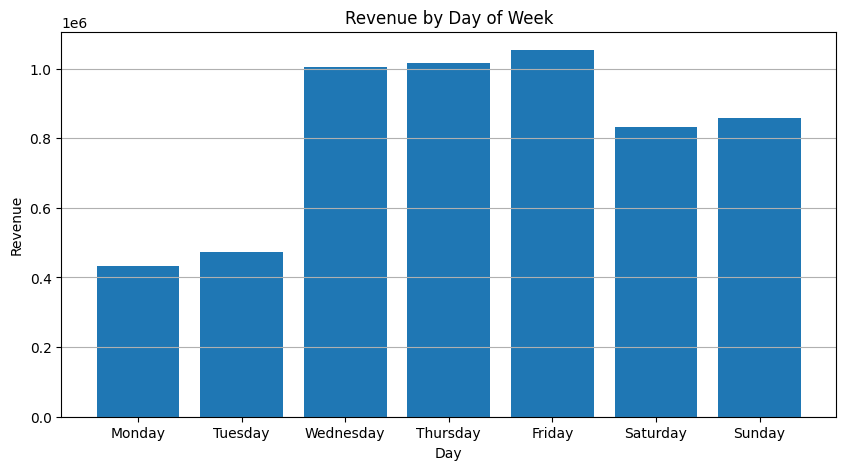

In [246]:
# Visualize Revenue by Day

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(

    daily_sales['Day_Name'],

    daily_sales['Revenue']

)

plt.xlabel('Day')

plt.ylabel('Revenue')

plt.title(

    'Revenue by Day of Week'

)

plt.grid(axis='y')

plt.show()

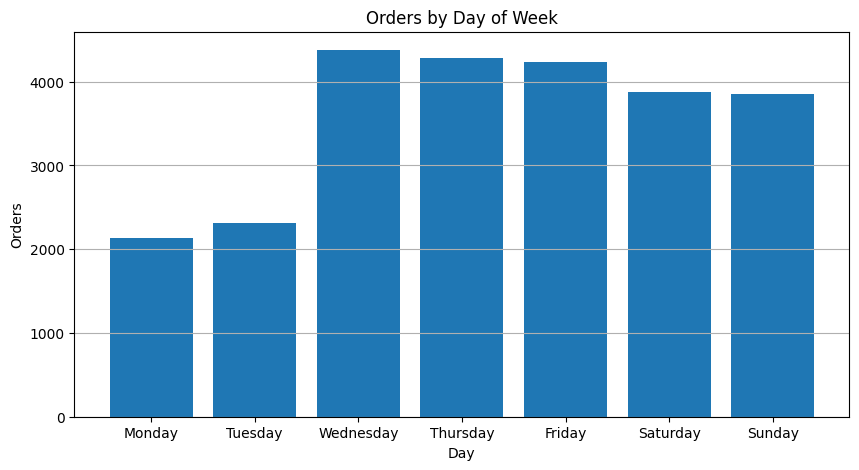

In [247]:
# Visualize Order Count

plt.figure(figsize=(10,5))

plt.bar(

    daily_sales['Day_Name'],

    daily_sales['Order_Count']

)

plt.xlabel('Day')

plt.ylabel('Orders')

plt.title(

    'Orders by Day of Week'

)

plt.grid(axis='y')

plt.show()

In [248]:
# Identify Slow Days
# Create a benchmark.

average_revenue = (

    daily_sales['Revenue']

    .mean()

)

slow_days = daily_sales.loc[

    daily_sales['Revenue']

    < average_revenue

]

slow_days

,Day_Number,Day_Name,Revenue,Order_Count,Avg_Order_Value,Quantity_Sold
0,0,Monday,434269.82992,2130,97.282668,11983
1,1,Tuesday,474374.02264,2315,102.878773,11317


In [249]:
# Categorize Days

daily_sales['Performance'] = (

    daily_sales['Revenue']

    .apply(

        lambda x:

        'High'

        if x >= average_revenue

        else 'Low'

    )

)

daily_sales

,Day_Number,Day_Name,Revenue,Order_Count,Avg_Order_Value,Quantity_Sold,Performance
0,0,Monday,4.342698e+05,2130,97.282668,11983,Low
1,1,Tuesday,4.743740e+05,2315,102.878773,11317,Low
2,2,Wednesday,1.005051e+06,4378,113.092305,39797,High
3,3,Thursday,1.016384e+06,4278,112.931572,44482,High
4,4,Friday,1.053075e+06,4233,113.649361,52433,High
5,5,Saturday,8.323910e+05,3872,101.796625,37965,High
6,6,Sunday,8.582005e+05,3855,100.739585,40056,High
